In [153]:
# Import dependencies for analysis

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats, optimize
import matplotlib.pyplot as plt


## Import Experimental Data

In [161]:
# Load data into dataframes

home = Path().resolve()

permeance = counter = pd.read_csv(f"{home}/data/permeance_data_collection.csv")
hybrid = pd.read_csv(f"{home}/data/air_separation_run_1.csv")
counter = pd.read_csv(f"{home}/data/air_separation_counter_current_run_1.csv")
co = pd.read_csv(f"{home}/data/air_separation_co_current_run_1.csv")
comp = pd.read_csv(f"{home}/data/comp_data.csv")

## Permeance and Selectivity Calculations

O2 Permeance:		0.0285
N2 Permeance:		0.0045
Selectivity (O2/N2):	6.3025



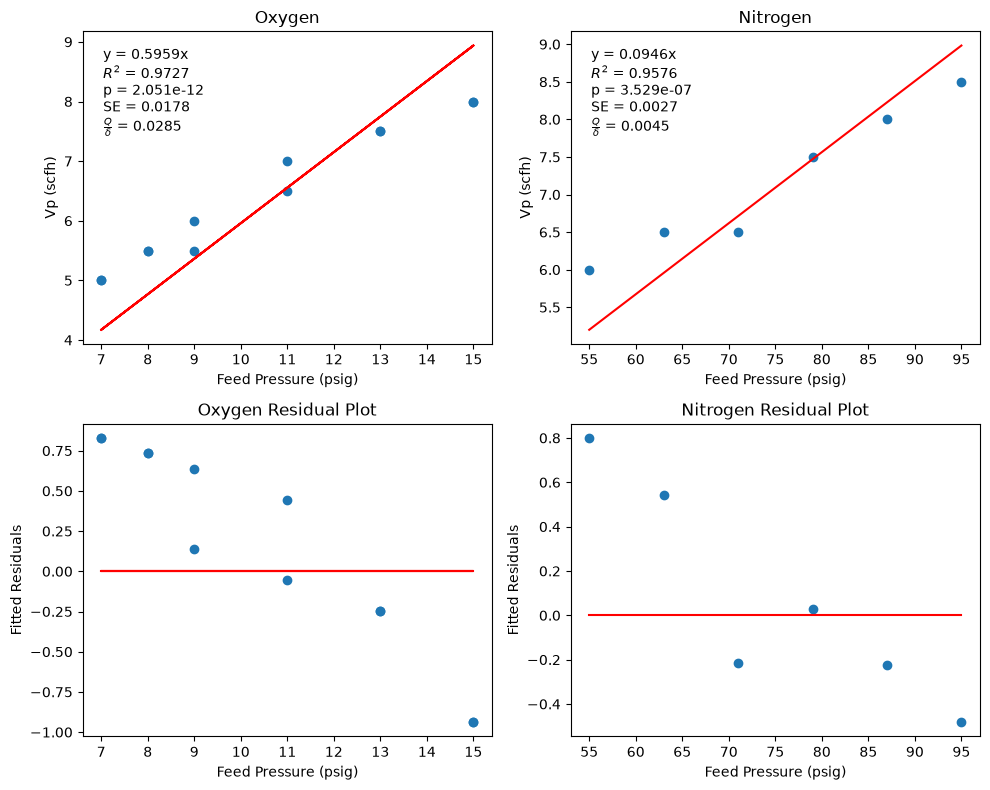

In [190]:
# Calculate permeance and selectivities from permeance dataframe

# Constrained linear regression function (y = mx)
def linest(x: pd.Series, y: pd.Series) -> tuple:
    """
    Linear least-squares regression forced through the origin: y = m*x.

    Returns:
        (slope, intercept, rvalue, pvalue, stderr, intercept_stderr)

    Notes:
        - intercept is always 0.0 because the model is constrained through
          the origin.
        - rvalue is the ordinary Pearson correlation coefficient, matching
          the meaning of scipy.stats.linregress().rvalue.
        - pvalue tests H0: slope = 0 for the no-intercept regression.
        - intercept_stderr is NaN because the intercept is fixed, not estimated.
    """

    # Put x and y together and remove paired NaN values
    data = pd.concat([x, y], axis=1).dropna()

    x = data.iloc[:, 0].to_numpy(dtype=float)
    y = data.iloc[:, 1].to_numpy(dtype=float)

    n = len(x)

    if n < 2:
        raise ValueError("At least two valid x-y pairs are required.")

    # ----- slope for y = mx -----
    sum_x2 = np.sum(x**2)

    if sum_x2 == 0:
        raise ValueError("Cannot perform regression when all x values are zero.")

    slope = np.sum(x * y) / sum_x2

    # ----- intercept -----
    intercept = 0.0

    # ----- residuals -----
    y_pred = slope * x
    residuals = y - y_pred

    # One fitted parameter: slope
    df = n - 1

    # Residual variance
    sse = np.sum(residuals**2)
    mse = sse / df

    # ----- standard error of slope -----
    stderr = np.sqrt(mse / sum_x2)

    # ----- hypothesis test H0: slope = 0 -----
    if stderr == 0:
        if slope == 0:
            pvalue = 1.0
        else:
            pvalue = 0.0
    else:
        t_stat = slope / stderr
        pvalue = 2 * stats.t.sf(np.abs(t_stat), df)

    # ----- Pearson correlation coefficient -----
    rvalue = stats.pearsonr(x, y).statistic

    # Intercept is constrained rather than estimated
    intercept_stderr = np.nan

    return (
        slope,
        intercept,
        rvalue,
        pvalue,
        stderr,
        intercept_stderr
    )

area = 9.86 # Membrane area is 9.86 m^2
scfh_to_slpm = 0.471947 # Conversion of scfh to slpm

# Split into individual species dataframes
oxygen_data = permeance[permeance["Species"] == "O2"]
nitrogen_data = permeance[permeance["Species"] == "N2"]

# Convert oxygen data into long dataframe
oxygen_long = oxygen_data.melt(
    id_vars=["Species", "Feed Pressure (psig)"],
    value_vars=["Vp (scfh), Rep 1", "Vp (scfh), Rep 2"],
    var_name="Replicate",
    value_name="Vp"
)

# Linear regression of y = mx
oxy_reg = linest(oxygen_long["Feed Pressure (psig)"], oxygen_long["Vp"]) 
nitro_reg = linest(nitrogen_data["Feed Pressure (psig)"], nitrogen_data["Vp (scfh), Rep 1"])

# Calculate vector of fitted values
oxy_fit = oxy_reg[0] * oxygen_long["Feed Pressure (psig)"]
nitro_fit = nitro_reg[0] * nitrogen_data["Feed Pressure (psig)"] 

# Calculate residuals of fit
oxy_res = oxygen_long["Vp"] - oxy_fit
nitro_res = nitrogen_data["Vp (scfh), Rep 1"] - nitro_fit

# Declare figures
pnsfig, pnsaxes = plt.subplots(2, 2, figsize=(10, 8))

# Calculate permeances and selectivities
O2_perm = (oxy_reg[0] * scfh_to_slpm) / area
N2_perm = (nitro_reg[0] * scfh_to_slpm) / area
alpha = O2_perm / N2_perm
print(
    f"O2 Permeance:\t\t{O2_perm:.4f}\n"
    f"N2 Permeance:\t\t{N2_perm:.4f}\n"
    f"Selectivity (O2/N2):\t{alpha:.4f}\n"
)

# Plot oxygen data
pnsaxes[0, 0].scatter(oxygen_long["Feed Pressure (psig)"], oxygen_long["Vp"])
pnsaxes[0, 0].plot(oxygen_long["Feed Pressure (psig)"], oxy_fit, c="red")
pnsaxes[0, 0].set_xlabel("Feed Pressure (psig)")
pnsaxes[0, 0].set_ylabel("Vp (scfh)")
pnsaxes[0, 0].set_title("Oxygen")
oxy_annotations = (
    f"y = {oxy_reg[0]:.4f}x\n"
    f"$R^2$ = {oxy_reg[2]**2:.4f}\n"
    f"p = {oxy_reg[3]:.3e}\n"
    f"SE = {oxy_reg[4]:.4f}\n"
    rf"$\frac{{Q}}{{\delta}}$ = {O2_perm:0.4f}"
)
pnsaxes[0, 0].text(
    0.05, 0.95,
    oxy_annotations,
    transform=pnsaxes[0, 0].transAxes,
    va="top"
)

# Plot nitrogen data
pnsaxes[0, 1].scatter(nitrogen_data["Feed Pressure (psig)"], nitrogen_data["Vp (scfh), Rep 1"])
pnsaxes[0, 1].plot(nitrogen_data["Feed Pressure (psig)"], nitro_fit, c="red")
pnsaxes[0, 1].set_xlabel("Feed Pressure (psig)")
pnsaxes[0, 1].set_ylabel("Vp (scfh)")
pnsaxes[0, 1].set_title("Nitrogen")
oxy_annotations = (
    f"y = {nitro_reg[0]:.4f}x\n"
    f"$R^2$ = {nitro_reg[2]**2:.4f}\n"
    f"p = {nitro_reg[3]:.3e}\n"
    f"SE = {nitro_reg[4]:.4f}\n"
    rf"$\frac{{Q}}{{\delta}}$ = {N2_perm:0.4f}"
)
pnsaxes[0, 1].text(
    0.05, 0.95,
    oxy_annotations,
    transform=pnsaxes[0, 1].transAxes,
    va="top"
)

# Plot residuals for oxygen
pnsaxes[1, 0].scatter(oxygen_long["Feed Pressure (psig)"], oxy_res)
pnsaxes[1, 0].plot(oxygen_long["Feed Pressure (psig)"], oxy_res * 0, c="red")
pnsaxes[1, 0].set_xlabel("Feed Pressure (psig)")
pnsaxes[1, 0].set_ylabel("Fitted Residuals")
pnsaxes[1, 0].set_title("Oxygen Residual Plot")

# Plot residuals for nitrogen
pnsaxes[1, 1].scatter(nitrogen_data["Feed Pressure (psig)"], nitro_res)
pnsaxes[1, 1].plot(nitrogen_data["Feed Pressure (psig)"], nitro_res * 0, c="red")
pnsaxes[1, 1].set_xlabel("Feed Pressure (psig)")
pnsaxes[1, 1].set_ylabel("Fitted Residuals")
pnsaxes[1, 1].set_title("Nitrogen Residual Plot")

pnsfig.tight_layout()
plt.show()

### Form summary dataframes to export as .csv ###

O2_perm_summary = pd.DataFrame({
    "Species": oxygen_long["Species"],
    "Feed Pressure": oxygen_long["Feed Pressure (psig)"],
    "Observed Flowrate (slpm)": oxygen_long["Vp"] * scfh_to_slpm,
    "Predicted Flowrate (slpm)": oxy_fit * scfh_to_slpm,
    "Residual": oxy_res * scfh_to_slpm
})

N2_perm_summary = pd.DataFrame({
    "Species": nitrogen_data["Species"],
    "Feed Pressure": nitrogen_data["Feed Pressure (psig)"],
    "Observed Flowrate (slpm)": nitrogen_data["Vp (scfh), Rep 1"] * scfh_to_slpm,
    "Predicted Flowrate (slpm)": nitro_fit * scfh_to_slpm,
    "Residual": nitro_res * scfh_to_slpm
})

# Compact data into summary sheets
permeance_fit_summary = pd.concat([O2_perm_summary, N2_perm_summary], ignore_index=True)
permeance_regression_summary = pd.DataFrame([["O2", *oxy_reg], ["N2", *nitro_reg]], columns=["species", "slope", "intercept", "R", "p", "slope stderr", "intercept stderr"])

# Write to file as .csv
permeance_fit_summary.to_csv(f"{home}/analyzed-data/permeance_fit_summary.csv")
permeance_regression_summary.to_csv(f"{home}/analyzed-data/permeance_regression_summary.csv")


## Full Series Air Separation

Pressure	Slope	Intercept	R2	p		m-stderr	int-stderr
120 psig	-0.3315	0.5260		0.9982	1.280e-06	0.0071		0.0024
100 psig	-0.3267	0.5180		0.9956	7.132e-06	0.0108		0.0036
80 psig		-0.2922	0.4898		0.9873	6.112e-05	0.0166		0.0056
Slope fit	-0.0010	-0.2185		0.8402	0.2618		0.0004		0.0434



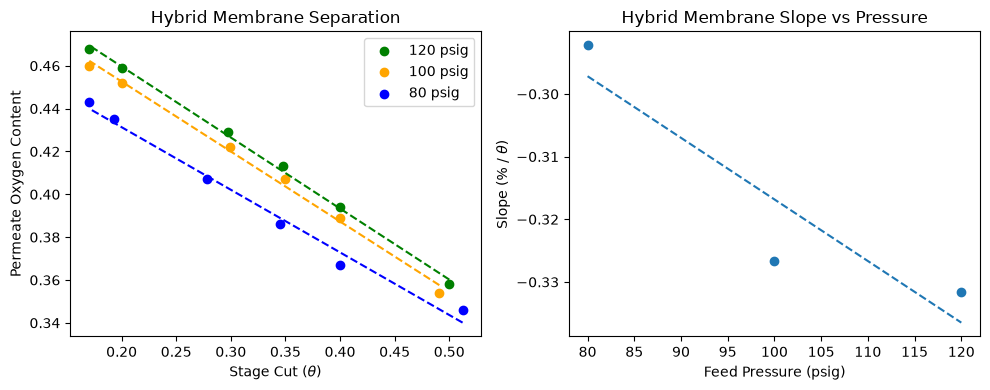

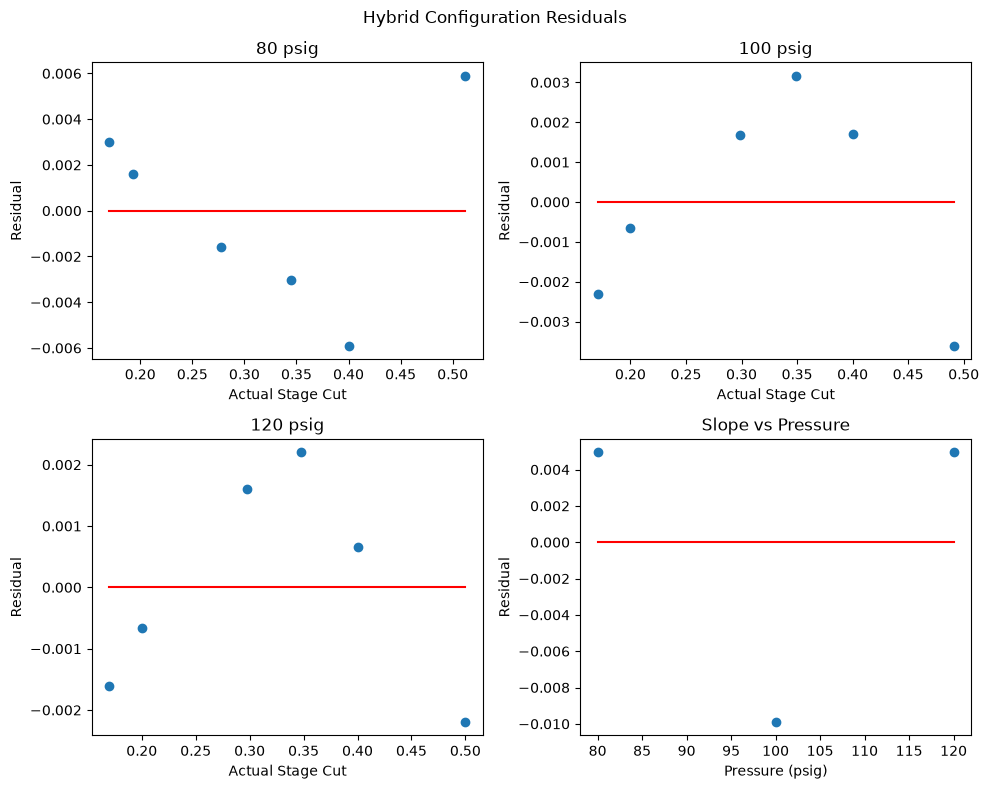

In [191]:
# This is to analyze the data from the dual hybrid air separation in series

# Declare plot object
hfig, hax = plt.subplots(1, 2, figsize=(10, 4))

# Separate hybrid data into individual pressure series
hp80 = hybrid[hybrid["Feed Pressure (psig) "] == 80]
hp100 = hybrid[hybrid["Feed Pressure (psig) "] == 100]
hp120 = hybrid[hybrid["Feed Pressure (psig) "] == 120]

# Fit the series
hp80reg = stats.linregress(hp80["Actual Stage Cut"], hp80["Permeate O2 Composition (%)"])
hp100reg = stats.linregress(hp100["Actual Stage Cut"], hp100["Permeate O2 Composition (%)"])
hp120reg = stats.linregress(hp120["Actual Stage Cut"], hp120["Permeate O2 Composition (%)"])

# Fit slope versus pressure
hsvspreg = stats.linregress([80, 100, 120], [hp80reg.slope, hp100reg.slope, hp120reg.slope])

# Create fitted vectors
hp80fit = hp80["Actual Stage Cut"] * hp80reg.slope + hp80reg.intercept
hp100fit = hp100["Actual Stage Cut"] * hp100reg.slope + hp100reg.intercept
hp120fit = hp120["Actual Stage Cut"] * hp120reg.slope + hp120reg.intercept

# Created fitted vector for slope vs pressure
hsvspfit = hsvspreg.slope * np.array([80, 100, 120]) + hsvspreg.intercept

# Print out values from regression
print(
    f"Pressure\tSlope\tIntercept\tR2\tp\t\tm-stderr\tint-stderr\n"
    f"120 psig\t{hp120reg.slope:.4f}\t{hp120reg.intercept:.4f}\t\t{hp120reg.rvalue**2:.4f}\t{hp120reg.pvalue:.3e}\t{hp120reg.stderr:.4f}\t\t{hp120reg.intercept_stderr:.4f}\n"
    f"100 psig\t{hp100reg.slope:.4f}\t{hp100reg.intercept:.4f}\t\t{hp100reg.rvalue**2:.4f}\t{hp100reg.pvalue:.3e}\t{hp100reg.stderr:.4f}\t\t{hp100reg.intercept_stderr:.4f}\n"
    f"80 psig\t\t{hp80reg.slope:.4f}\t{hp80reg.intercept:.4f}\t\t{hp80reg.rvalue**2:.4f}\t{hp80reg.pvalue:.3e}\t{hp80reg.stderr:.4f}\t\t{hp80reg.intercept_stderr:.4f}\n"
    f"Slope fit\t{hsvspreg.slope:.4f}\t{hsvspreg.intercept:.4f}\t\t{hsvspreg.rvalue**2:.4f}\t{hsvspreg.pvalue:.4f}\t\t{hsvspreg.stderr:.4f}\t\t{hsvspreg.intercept_stderr:.4f}\n"   
)

# Plot the observed data ** Order of plotting masters for visual clarity (order on the legend)
hax[0].scatter(hp120["Actual Stage Cut"], hp120["Permeate O2 Composition (%)"], label="120 psig", c="green")
hax[0].scatter(hp100["Actual Stage Cut"], hp100["Permeate O2 Composition (%)"], label="100 psig", c="orange")
hax[0].scatter(hp80["Actual Stage Cut"], hp80["Permeate O2 Composition (%)"], label="80 psig", c="blue")

# Plot fitted data
hax[0].plot(hp80["Actual Stage Cut"], hp80fit, c="blue", ls="--")
hax[0].plot(hp100["Actual Stage Cut"], hp100fit, c="orange", ls="--")
hax[0].plot(hp120["Actual Stage Cut"], hp120fit, c="green", ls="--")

# Label the chart
hax[0].set_xlabel(rf"Stage Cut ($\theta$)")
hax[0].set_ylabel("Permeate Oxygen Content")
hax[0].set_title("Hybrid Membrane Separation")
hax[0].legend()

# Plot separation slope vs pressure
hax[1].scatter([80, 100, 120], [hp80reg.slope, hp100reg.slope, hp120reg.slope])
hax[1].plot([80, 100, 120], hsvspfit, ls="--")
hax[1].set_xlabel("Feed Pressure (psig)")
hax[1].set_ylabel(rf"Slope (% / $\theta$)")
hax[1].set_title("Hybrid Membrane Slope vs Pressure")

# Fix formatting
hfig.tight_layout()

# Calculate Residuals
hp80res = hp80["Permeate O2 Composition (%)"] - hp80fit
hp100res = hp100["Permeate O2 Composition (%)"] - hp100fit
hp120res = hp120["Permeate O2 Composition (%)"] - hp120fit
hpsvspres = np.array([hp80reg.slope, hp100reg.slope, hp120reg.slope]) - hsvspfit

### Plot residuals ###
hrfig, hraxes = plt.subplots(2, 2, figsize=(10, 8))

# 80 psig residuals
hraxes[0, 0].scatter(hp80["Actual Stage Cut"], hp80res)
hraxes[0, 0].plot(hp80["Actual Stage Cut"], hp80res * 0, c="red")
hraxes[0, 0].set_xlabel("Actual Stage Cut")
hraxes[0, 0].set_ylabel("Residual")
hraxes[0, 0].set_title("80 psig")

# 100 psig residuals
hraxes[0, 1].scatter(hp100["Actual Stage Cut"], hp100res)
hraxes[0, 1].plot(hp100["Actual Stage Cut"], 0 * hp100res, c="red")
hraxes[0, 1].set_xlabel("Actual Stage Cut")
hraxes[0, 1].set_ylabel("Residual")
hraxes[0, 1].set_title("100 psig")

# 120 psig residuals
hraxes[1, 0].scatter(hp120["Actual Stage Cut"], hp120res)
hraxes[1, 0].plot(hp120["Actual Stage Cut"], 0 * hp120res, c="red")
hraxes[1, 0].set_xlabel("Actual Stage Cut")
hraxes[1, 0].set_ylabel("Residual")
hraxes[1, 0].set_title("120 psig")

# Slope vs pressure residuals
hraxes[1, 1].scatter([80, 100, 120], hpsvspres)
hraxes[1, 1].plot([80, 100, 120], 0 * hpsvspres, c="red")
hraxes[1, 1].set_xlabel("Pressure (psig)")
hraxes[1, 1].set_ylabel("Residual")
hraxes[1, 1].set_title("Slope vs Pressure")

hrfig.suptitle("Hybrid Configuration Residuals")
hrfig.tight_layout()

plt.show()

### Saving Data ###

### Export hybrid regression data ###

# ----------------------------
# Build fit summary dataframe
# ----------------------------

# 80 psig series
hp80out = pd.DataFrame({
    "Series": "80 psig",
    "X": hp80["Actual Stage Cut"].to_numpy(),
    "Observed": hp80["Permeate O2 Composition (%)"].to_numpy(),
    "Predicted": hp80fit.to_numpy(),
    "Residual": hp80res.to_numpy()
})

# 100 psig series
hp100out = pd.DataFrame({
    "Series": "100 psig",
    "X": hp100["Actual Stage Cut"].to_numpy(),
    "Observed": hp100["Permeate O2 Composition (%)"].to_numpy(),
    "Predicted": hp100fit.to_numpy(),
    "Residual": hp100res.to_numpy()
})

# 120 psig series
hp120out = pd.DataFrame({
    "Series": "120 psig",
    "X": hp120["Actual Stage Cut"].to_numpy(),
    "Observed": hp120["Permeate O2 Composition (%)"].to_numpy(),
    "Predicted": hp120fit.to_numpy(),
    "Residual": hp120res.to_numpy()
})

# Slope vs pressure series
hsvspout = pd.DataFrame({
    "Series": "Slope vs Pressure",
    "X": [80, 100, 120],
    "Observed": [hp80reg.slope, hp100reg.slope, hp120reg.slope],
    "Predicted": hsvspfit,
    "Residual": hpsvspres
})

# Stack all fit data into one dataframe
hfit = pd.concat(
    [hp80out, hp100out, hp120out, hsvspout],
    ignore_index=True
)


# ----------------------------------
# Build regression summary dataframe
# ----------------------------------

hreg = pd.DataFrame(
    [
        [
            "80 psig",
            hp80reg.slope,
            hp80reg.intercept,
            hp80reg.rvalue**2,
            hp80reg.pvalue,
            hp80reg.stderr,
            hp80reg.intercept_stderr
        ],
        [
            "100 psig",
            hp100reg.slope,
            hp100reg.intercept,
            hp100reg.rvalue**2,
            hp100reg.pvalue,
            hp100reg.stderr,
            hp100reg.intercept_stderr
        ],
        [
            "120 psig",
            hp120reg.slope,
            hp120reg.intercept,
            hp120reg.rvalue**2,
            hp120reg.pvalue,
            hp120reg.stderr,
            hp120reg.intercept_stderr
        ],
        [
            "Slope vs Pressure",
            hsvspreg.slope,
            hsvspreg.intercept,
            hsvspreg.rvalue**2,
            hsvspreg.pvalue,
            hsvspreg.stderr,
            hsvspreg.intercept_stderr
        ]
    ],
    columns=[
        "Series",
        "slope",
        "intercept",
        "R2",
        "p",
        "slope stderr",
        "intercept stderr"
    ]
)


# ----------------------------
# Export CSV files
# ----------------------------

hfit.to_csv(
    f"{home}/analyzed-data/hybrid_fit_summary.csv",
    index=False
)

hreg.to_csv(
    f"{home}/analyzed-data/hybrid_regression_summary.csv",
    index=False
)



## Counter-Current Air Separation

Pressure	Slope	Intercept	R2	p		m-stderr	int-stderr
120 psig	-0.3548	0.5519		0.9940	2.983e-03	0.0194		0.0051
100 psig	-0.3333	0.5371		0.9984	8.252e-04	0.0096		0.0026
80 psig		-0.2881	0.5194		0.9982	8.787e-04	0.0085		0.0023
Slope fit	-0.0017	-0.1588		0.9594	0.1291		0.0003		0.0347



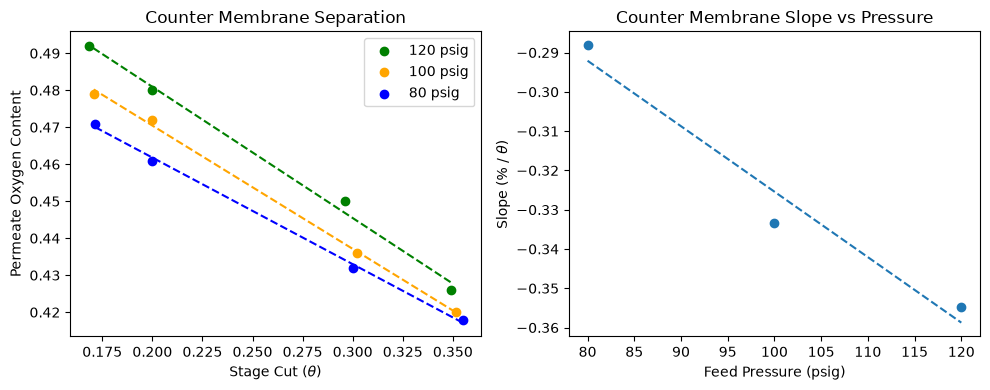

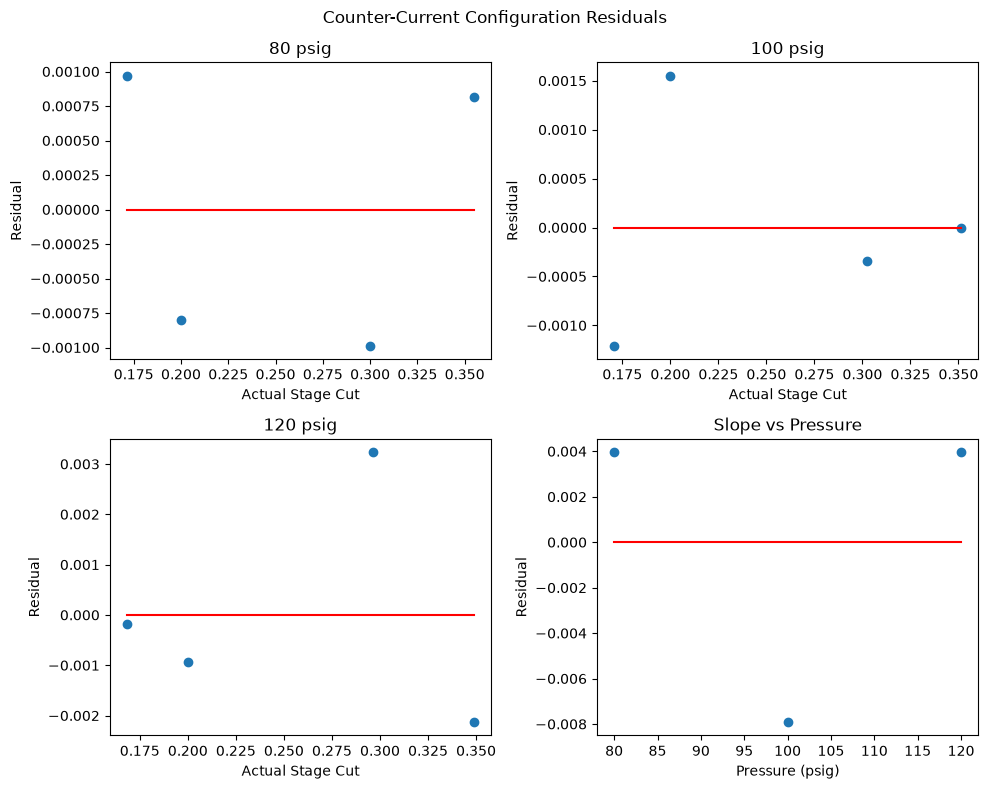

In [192]:
# This is to analyze the data from the counter current air separation in series

# Declare plot object
cnfig, cnax = plt.subplots(1, 2, figsize=(10, 4))

# Separate counter data into individual pressure series
cnp80 = counter[counter["Feed Pressure (psig) "] == 80]
cnp100 = counter[counter["Feed Pressure (psig) "] == 100]
cnp120 = counter[counter["Feed Pressure (psig) "] == 120]

# Fit the series
cnp80reg = stats.linregress(cnp80["Actual Stage Cut"], cnp80["Permeate O2 Composition (%)"])
cnp100reg = stats.linregress(cnp100["Actual Stage Cut"], cnp100["Permeate O2 Composition (%)"])
cnp120reg = stats.linregress(cnp120["Actual Stage Cut"], cnp120["Permeate O2 Composition (%)"])

# Fit slope versus pressure to gauge
cnsvspreg = stats.linregress([80, 100, 120], [cnp80reg.slope, cnp100reg.slope, cnp120reg.slope])

# Create fitted vectors
cnp80fit = cnp80["Actual Stage Cut"] * cnp80reg.slope + cnp80reg.intercept
cnp100fit = cnp100["Actual Stage Cut"] * cnp100reg.slope + cnp100reg.intercept
cnp120fit = cnp120["Actual Stage Cut"] * cnp120reg.slope + cnp120reg.intercept

# Created fitted vector for slope vs pressure
cnsvspfit = cnsvspreg.slope * np.array([80, 100, 120]) + cnsvspreg.intercept

# Print out values from regression
print(
    f"Pressure\tSlope\tIntercept\tR2\tp\t\tm-stderr\tint-stderr\n"
    f"120 psig\t{cnp120reg.slope:.4f}\t{cnp120reg.intercept:.4f}\t\t{cnp120reg.rvalue**2:.4f}\t{cnp120reg.pvalue:.3e}\t{cnp120reg.stderr:.4f}\t\t{cnp120reg.intercept_stderr:.4f}\n"
    f"100 psig\t{cnp100reg.slope:.4f}\t{cnp100reg.intercept:.4f}\t\t{cnp100reg.rvalue**2:.4f}\t{cnp100reg.pvalue:.3e}\t{cnp100reg.stderr:.4f}\t\t{cnp100reg.intercept_stderr:.4f}\n"
    f"80 psig\t\t{cnp80reg.slope:.4f}\t{cnp80reg.intercept:.4f}\t\t{cnp80reg.rvalue**2:.4f}\t{cnp80reg.pvalue:.3e}\t{cnp80reg.stderr:.4f}\t\t{cnp80reg.intercept_stderr:.4f}\n"
    f"Slope fit\t{cnsvspreg.slope:.4f}\t{cnsvspreg.intercept:.4f}\t\t{cnsvspreg.rvalue**2:.4f}\t{cnsvspreg.pvalue:.4f}\t\t{cnsvspreg.stderr:.4f}\t\t{cnsvspreg.intercept_stderr:.4f}\n"   
)

# Plot the observed data ** Order of plotting masters for visual clarity (order on the legend)
cnax[0].scatter(cnp120["Actual Stage Cut"], cnp120["Permeate O2 Composition (%)"], label="120 psig", c="green")
cnax[0].scatter(cnp100["Actual Stage Cut"], cnp100["Permeate O2 Composition (%)"], label="100 psig", c="orange")
cnax[0].scatter(cnp80["Actual Stage Cut"], cnp80["Permeate O2 Composition (%)"], label="80 psig", c="blue")

# Plot fitted data
cnax[0].plot(cnp80["Actual Stage Cut"], cnp80fit, c="blue", ls="--")
cnax[0].plot(cnp100["Actual Stage Cut"], cnp100fit, c="orange", ls="--")
cnax[0].plot(cnp120["Actual Stage Cut"], cnp120fit, c="green", ls="--")

# Label the chart
cnax[0].set_xlabel(rf"Stage Cut ($\theta$)")
cnax[0].set_ylabel("Permeate Oxygen Content")
cnax[0].set_title("Counter Membrane Separation")
cnax[0].legend()

# Plot separation slope vs pressure
cnax[1].scatter([80, 100, 120], [cnp80reg.slope, cnp100reg.slope, cnp120reg.slope])
cnax[1].plot([80, 100, 120], cnsvspfit, ls="--")
cnax[1].set_xlabel("Feed Pressure (psig)")
cnax[1].set_ylabel(rf"Slope (% / $\theta$)")
cnax[1].set_title("Counter Membrane Slope vs Pressure")

cnfig.tight_layout()

# Calculate Residuals
cnp80res = cnp80["Permeate O2 Composition (%)"] - cnp80fit
cnp100res = cnp100["Permeate O2 Composition (%)"] - cnp100fit
cnp120res = cnp120["Permeate O2 Composition (%)"] - cnp120fit
cnpsvspres = np.array([cnp80reg.slope, cnp100reg.slope, cnp120reg.slope]) - cnsvspfit

### Plot residuals ###
cnrfig, cnraxes = plt.subplots(2, 2, figsize=(10, 8))

# 80 psig residuals
cnraxes[0, 0].scatter(cnp80["Actual Stage Cut"], cnp80res)
cnraxes[0, 0].plot(cnp80["Actual Stage Cut"], cnp80res * 0, c="red")
cnraxes[0, 0].set_xlabel("Actual Stage Cut")
cnraxes[0, 0].set_ylabel("Residual")
cnraxes[0, 0].set_title("80 psig")

# 100 psig residuals
cnraxes[0, 1].scatter(cnp100["Actual Stage Cut"], cnp100res)
cnraxes[0, 1].plot(cnp100["Actual Stage Cut"], 0 * cnp100res, c="red")
cnraxes[0, 1].set_xlabel("Actual Stage Cut")
cnraxes[0, 1].set_ylabel("Residual")
cnraxes[0, 1].set_title("100 psig")

# 120 psig residuals
cnraxes[1, 0].scatter(cnp120["Actual Stage Cut"], cnp120res)
cnraxes[1, 0].plot(cnp120["Actual Stage Cut"], 0 * cnp120res, c="red")
cnraxes[1, 0].set_xlabel("Actual Stage Cut")
cnraxes[1, 0].set_ylabel("Residual")
cnraxes[1, 0].set_title("120 psig")

# Slope vs pressure residuals
cnraxes[1, 1].scatter([80, 100, 120], cnpsvspres)
cnraxes[1, 1].plot([80, 100, 120], 0 * cnpsvspres, c="red")
cnraxes[1, 1].set_xlabel("Pressure (psig)")
cnraxes[1, 1].set_ylabel("Residual")
cnraxes[1, 1].set_title("Slope vs Pressure")

cnrfig.suptitle("Counter-Current Configuration Residuals")
cnrfig.tight_layout()

plt.show()

### Export counter-current regression data ###

# ----------------------------
# Build fit summary dataframe
# ----------------------------

# 80 psig series
cnp80out = pd.DataFrame({
    "Series": "80 psig",
    "X": cnp80["Actual Stage Cut"].to_numpy(),
    "Observed": cnp80["Permeate O2 Composition (%)"].to_numpy(),
    "Predicted": cnp80fit.to_numpy(),
    "Residual": cnp80res.to_numpy()
})

# 100 psig series
cnp100out = pd.DataFrame({
    "Series": "100 psig",
    "X": cnp100["Actual Stage Cut"].to_numpy(),
    "Observed": cnp100["Permeate O2 Composition (%)"].to_numpy(),
    "Predicted": cnp100fit.to_numpy(),
    "Residual": cnp100res.to_numpy()
})

# 120 psig series
cnp120out = pd.DataFrame({
    "Series": "120 psig",
    "X": cnp120["Actual Stage Cut"].to_numpy(),
    "Observed": cnp120["Permeate O2 Composition (%)"].to_numpy(),
    "Predicted": cnp120fit.to_numpy(),
    "Residual": cnp120res.to_numpy()
})

# Slope vs pressure series
cnsvspout = pd.DataFrame({
    "Series": "Slope vs Pressure",
    "X": [80, 100, 120],
    "Observed": [cnp80reg.slope, cnp100reg.slope, cnp120reg.slope],
    "Predicted": cnsvspfit,
    "Residual": cnpsvspres
})

# Stack all fit data into one dataframe
cnfit = pd.concat(
    [cnp80out, cnp100out, cnp120out, cnsvspout],
    ignore_index=True
)


# ----------------------------------
# Build regression summary dataframe
# ----------------------------------

cnreg = pd.DataFrame(
    [
        [
            "80 psig",
            cnp80reg.slope,
            cnp80reg.intercept,
            cnp80reg.rvalue**2,
            cnp80reg.pvalue,
            cnp80reg.stderr,
            cnp80reg.intercept_stderr
        ],
        [
            "100 psig",
            cnp100reg.slope,
            cnp100reg.intercept,
            cnp100reg.rvalue**2,
            cnp100reg.pvalue,
            cnp100reg.stderr,
            cnp100reg.intercept_stderr
        ],
        [
            "120 psig",
            cnp120reg.slope,
            cnp120reg.intercept,
            cnp120reg.rvalue**2,
            cnp120reg.pvalue,
            cnp120reg.stderr,
            cnp120reg.intercept_stderr
        ],
        [
            "Slope vs Pressure",
            cnsvspreg.slope,
            cnsvspreg.intercept,
            cnsvspreg.rvalue**2,
            cnsvspreg.pvalue,
            cnsvspreg.stderr,
            cnsvspreg.intercept_stderr
        ]
    ],
    columns=[
        "Series",
        "slope",
        "intercept",
        "R2",
        "p",
        "slope stderr",
        "intercept stderr"
    ]
)


# ----------------------------
# Export CSV files
# ----------------------------

cnfit.to_csv(
    f"{home}/analyzed-data/counter_fit_summary.csv",
    index=False
)

cnreg.to_csv(
    f"{home}/analyzed-data/counter_regression_summary.csv",
    index=False
)

## Co-Current Air Separation

Pressure	Slope	Intercept	R2	p		m-stderr	int-stderr
120 psig	-0.3165	0.5062		0.9991	4.386e-04	0.0066		0.0018
100 psig	-0.2670	0.4795		0.9842	7.920e-03	0.0239		0.0063
80 psig		-0.2462	0.4667		0.9981	9.592e-04	0.0076		0.0020
Slope fit	-0.0018	-0.1010		0.9473	0.1474		0.0004		0.0420



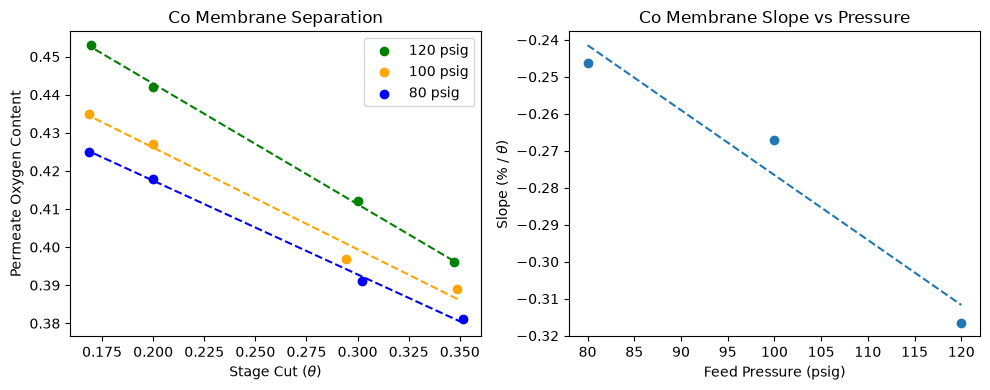

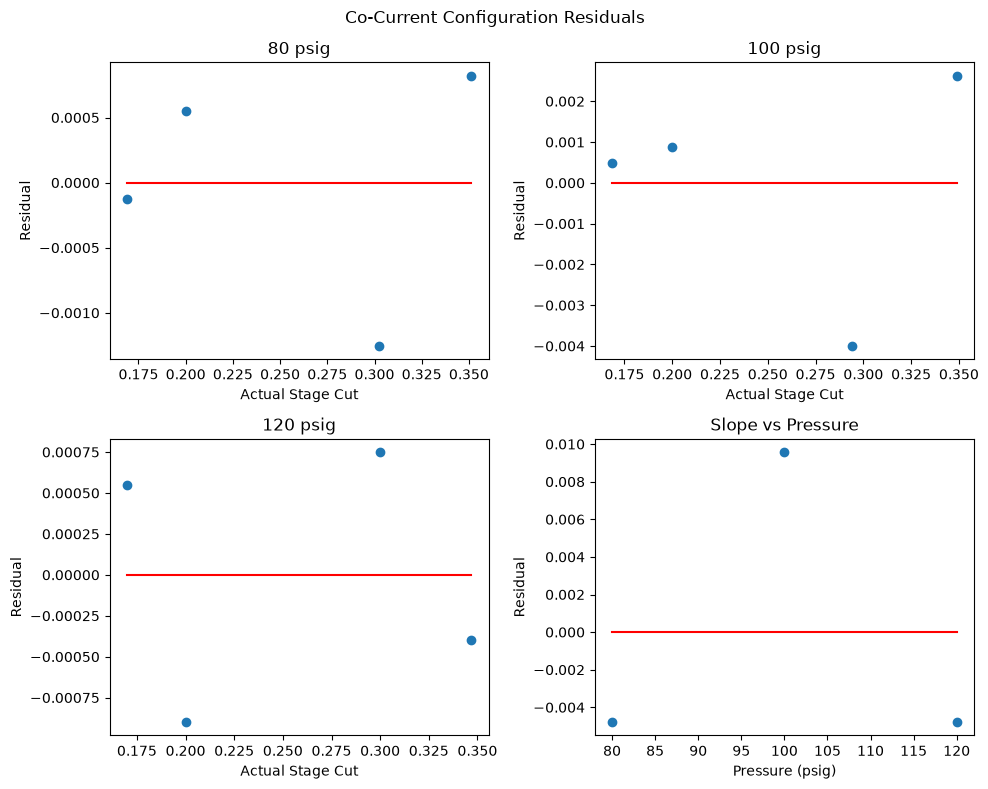

In [193]:
# This is to analyze the data from the counter current air separation in series

# Declare plot object
cfig, cax = plt.subplots(1, 2, figsize=(10, 4))

# Separate co data into individual pressure series
cp80 = co[co["Feed Pressure (psig) "] == 80]
cp100 = co[co["Feed Pressure (psig) "] == 100]
cp120 = co[co["Feed Pressure (psig) "] == 120]

# Fit the series
cp80reg = stats.linregress(cp80["Actual Stage Cut"], cp80["Permeate O2 Composition (%)"])
cp100reg = stats.linregress(cp100["Actual Stage Cut"], cp100["Permeate O2 Composition (%)"])
cp120reg = stats.linregress(cp120["Actual Stage Cut"], cp120["Permeate O2 Composition (%)"])

# Fit slope versus pressure to gauge
csvspreg = stats.linregress([80, 100, 120], [cp80reg.slope, cp100reg.slope, cp120reg.slope])

# Create fitted vectors
cp80fit = cp80["Actual Stage Cut"] * cp80reg.slope + cp80reg.intercept
cp100fit = cp100["Actual Stage Cut"] * cp100reg.slope + cp100reg.intercept
cp120fit = cp120["Actual Stage Cut"] * cp120reg.slope + cp120reg.intercept

# Created fitted vector for slope vs pressure
csvspfit = csvspreg.slope * np.array([80, 100, 120]) + csvspreg.intercept

# Print out values from regression
print(
    f"Pressure\tSlope\tIntercept\tR2\tp\t\tm-stderr\tint-stderr\n"
    f"120 psig\t{cp120reg.slope:.4f}\t{cp120reg.intercept:.4f}\t\t{cp120reg.rvalue**2:.4f}\t{cp120reg.pvalue:.3e}\t{cp120reg.stderr:.4f}\t\t{cp120reg.intercept_stderr:.4f}\n"
    f"100 psig\t{cp100reg.slope:.4f}\t{cp100reg.intercept:.4f}\t\t{cp100reg.rvalue**2:.4f}\t{cp100reg.pvalue:.3e}\t{cp100reg.stderr:.4f}\t\t{cp100reg.intercept_stderr:.4f}\n"
    f"80 psig\t\t{cp80reg.slope:.4f}\t{cp80reg.intercept:.4f}\t\t{cp80reg.rvalue**2:.4f}\t{cp80reg.pvalue:.3e}\t{cp80reg.stderr:.4f}\t\t{cp80reg.intercept_stderr:.4f}\n"
    f"Slope fit\t{csvspreg.slope:.4f}\t{csvspreg.intercept:.4f}\t\t{csvspreg.rvalue**2:.4f}\t{csvspreg.pvalue:.4f}\t\t{csvspreg.stderr:.4f}\t\t{csvspreg.intercept_stderr:.4f}\n" 
)

# Plot the observed data ** Order of plotting masters for visual clarity (order on the legend)
cax[0].scatter(cp120["Actual Stage Cut"], cp120["Permeate O2 Composition (%)"], label="120 psig", c="green")
cax[0].scatter(cp100["Actual Stage Cut"], cp100["Permeate O2 Composition (%)"], label="100 psig", c="orange")
cax[0].scatter(cp80["Actual Stage Cut"], cp80["Permeate O2 Composition (%)"], label="80 psig", c="blue")

# Plot fitted data
cax[0].plot(cp80["Actual Stage Cut"], cp80fit, c="blue", ls="--")
cax[0].plot(cp100["Actual Stage Cut"], cp100fit, c="orange", ls="--")
cax[0].plot(cp120["Actual Stage Cut"], cp120fit, c="green", ls="--")

# Label the chart
cax[0].set_xlabel(rf"Stage Cut ($\theta$)")
cax[0].set_ylabel("Permeate Oxygen Content")
cax[0].set_title("Co Membrane Separation")
cax[0].legend()

# Plot separation slope vs pressure
cax[1].scatter([80, 100, 120], [cp80reg.slope, cp100reg.slope, cp120reg.slope])
cax[1].plot([80, 100, 120], csvspfit, ls="--")
cax[1].set_xlabel("Feed Pressure (psig)")
cax[1].set_ylabel(rf"Slope (% / $\theta$)")
cax[1].set_title("Co Membrane Slope vs Pressure")

cfig.tight_layout()

# Calculate Residuals
cp80res = cp80["Permeate O2 Composition (%)"] - cp80fit
cp100res = cp100["Permeate O2 Composition (%)"] - cp100fit
cp120res = cp120["Permeate O2 Composition (%)"] - cp120fit
cpsvspres = np.array([cp80reg.slope, cp100reg.slope, cp120reg.slope]) - csvspfit

### Plot residuals ###
crfig, craxes = plt.subplots(2, 2, figsize=(10, 8))

# 80 psig residuals
craxes[0, 0].scatter(cp80["Actual Stage Cut"], cp80res)
craxes[0, 0].plot(cp80["Actual Stage Cut"], cp80res * 0, c="red")
craxes[0, 0].set_xlabel("Actual Stage Cut")
craxes[0, 0].set_ylabel("Residual")
craxes[0, 0].set_title("80 psig")

# 100 psig residuals
craxes[0, 1].scatter(cp100["Actual Stage Cut"], cp100res)
craxes[0, 1].plot(cp100["Actual Stage Cut"], 0 * cp100res, c="red")
craxes[0, 1].set_xlabel("Actual Stage Cut")
craxes[0, 1].set_ylabel("Residual")
craxes[0, 1].set_title("100 psig")

# 120 psig residuals
craxes[1, 0].scatter(cp120["Actual Stage Cut"], cp120res)
craxes[1, 0].plot(cp120["Actual Stage Cut"], 0 * cp120res, c="red")
craxes[1, 0].set_xlabel("Actual Stage Cut")
craxes[1, 0].set_ylabel("Residual")
craxes[1, 0].set_title("120 psig")

# Slope vs pressure residuals
craxes[1, 1].scatter([80, 100, 120], cpsvspres)
craxes[1, 1].plot([80, 100, 120], 0 * cpsvspres, c="red")
craxes[1, 1].set_xlabel("Pressure (psig)")
craxes[1, 1].set_ylabel("Residual")
craxes[1, 1].set_title("Slope vs Pressure")

crfig.suptitle("Co-Current Configuration Residuals")
crfig.tight_layout()

plt.show()

### Export co-current regression data ###

# ----------------------------
# Build fit summary dataframe
# ----------------------------

# 80 psig series
cp80out = pd.DataFrame({
    "Series": "80 psig",
    "X": cp80["Actual Stage Cut"].to_numpy(),
    "Observed": cp80["Permeate O2 Composition (%)"].to_numpy(),
    "Predicted": cp80fit.to_numpy(),
    "Residual": cp80res.to_numpy()
})

# 100 psig series
cp100out = pd.DataFrame({
    "Series": "100 psig",
    "X": cp100["Actual Stage Cut"].to_numpy(),
    "Observed": cp100["Permeate O2 Composition (%)"].to_numpy(),
    "Predicted": cp100fit.to_numpy(),
    "Residual": cp100res.to_numpy()
})

# 120 psig series
cp120out = pd.DataFrame({
    "Series": "120 psig",
    "X": cp120["Actual Stage Cut"].to_numpy(),
    "Observed": cp120["Permeate O2 Composition (%)"].to_numpy(),
    "Predicted": cp120fit.to_numpy(),
    "Residual": cp120res.to_numpy()
})

# Slope vs pressure series
csvspout = pd.DataFrame({
    "Series": "Slope vs Pressure",
    "X": [80, 100, 120],
    "Observed": [cp80reg.slope, cp100reg.slope, cp120reg.slope],
    "Predicted": csvspfit,
    "Residual": cpsvspres
})

# Stack all fit data into one dataframe
cfit = pd.concat(
    [cp80out, cp100out, cp120out, csvspout],
    ignore_index=True
)


# ----------------------------------
# Build regression summary dataframe
# ----------------------------------

creg = pd.DataFrame(
    [
        [
            "80 psig",
            cp80reg.slope,
            cp80reg.intercept,
            cp80reg.rvalue**2,
            cp80reg.pvalue,
            cp80reg.stderr,
            cp80reg.intercept_stderr
        ],
        [
            "100 psig",
            cp100reg.slope,
            cp100reg.intercept,
            cp100reg.rvalue**2,
            cp100reg.pvalue,
            cp100reg.stderr,
            cp100reg.intercept_stderr
        ],
        [
            "120 psig",
            cp120reg.slope,
            cp120reg.intercept,
            cp120reg.rvalue**2,
            cp120reg.pvalue,
            cp120reg.stderr,
            cp120reg.intercept_stderr
        ],
        [
            "Slope vs Pressure",
            csvspreg.slope,
            csvspreg.intercept,
            csvspreg.rvalue**2,
            csvspreg.pvalue,
            csvspreg.stderr,
            csvspreg.intercept_stderr
        ]
    ],
    columns=[
        "Series",
        "slope",
        "intercept",
        "R2",
        "p",
        "slope stderr",
        "intercept stderr"
    ]
)


# ----------------------------
# Export CSV files
# ----------------------------

cfit.to_csv(
    f"{home}/analyzed-data/co_fit_summary.csv",
    index=False
)

creg.to_csv(
    f"{home}/analyzed-data/co_regression_summary.csv",
    index=False
)

## Membrane Simulater

In [ ]:
def membrane_stage(F, z, A, perm_O2, alpha, PR, PP=14.7):

    def residuals(x):
        VR, VP, yR, yP = x

        # Perfect-mixing RT equation
        yR_RT = yP * ((alpha - 1) * (PP / PR) * (1 - yP) + 1) / (alpha - yP * (alpha - 1))

        # Scale flow residuals by F so all residuals
        # are roughly comparable in magnitude
        r1 = (VR + VP - F) / F

        r2 = (yR * VR + yP * VP - z * F) / F

        r3 = (yP * VP - perm_O2 * A * (yR * PR - yP * PP)) / F

        r4 = yR - yR_RT

        return [r1, r2, r3, r4]

    # Initial guess
    theta_guess = 0.25

    VP_guess = theta_guess * F
    VR_guess = F - VP_guess

    yP_guess = min(z * 1.8, 0.95)

    yR_guess = (
        z * F - yP_guess * VP_guess
    ) / VR_guess

    yR_guess = np.clip(yR_guess, 0.001, 0.999)

    x0 = [
        VR_guess,
        VP_guess,
        yR_guess,
        yP_guess,
    ]

    # Physical bounds
    lower = [0, 0, 0, 0]
    upper = [F, F, 1, 1]

    solution = optimize.least_squares(
        residuals,
        x0,
        bounds=(lower, upper)
    )

    if not solution.success:
        raise RuntimeError("Membrane solver did not converge")

    VR, VP, yR, yP = solution.x

    return {
        "retentate_flow": VR,
        "permeate_flow": VP,
        "retentate_O2": yR,
        "permeate_O2": yP,
        "stage_cut": VP / F,
    }





## Testing the Configurations and Plotting

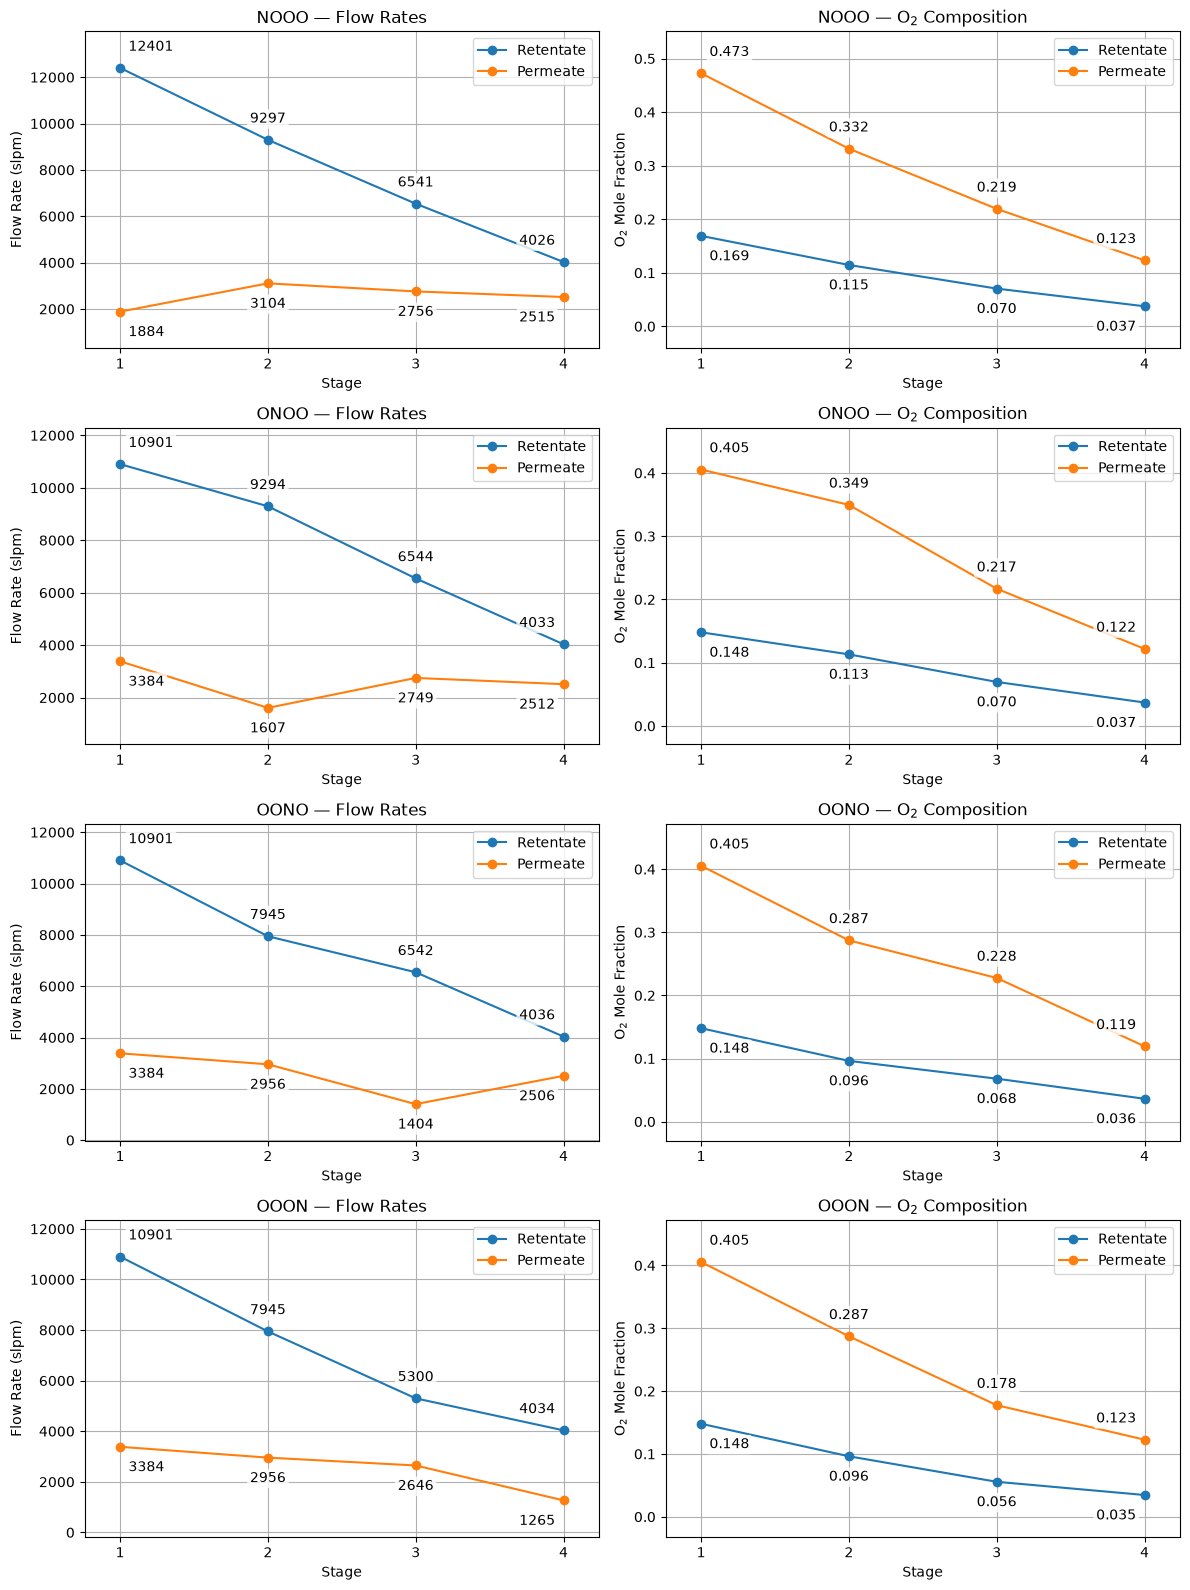


========== NOOO ==========
 retentate_flow  permeate_flow  retentate_O2  permeate_O2  stage_cut  stage membrane configuration
   12401.223323    1883.776677      0.168964     0.472567   0.131871      1        N          NOOO
    9297.423724    3103.799597      0.114617     0.331758   0.250282      2        O          NOOO
    6541.312387    2756.111338      0.070458     0.219424   0.296438      3        O          NOOO
    4026.417512    2514.894875      0.037489     0.123242   0.384463      4        O          NOOO

========== ONOO ==========
 retentate_flow  permeate_flow  retentate_O2  permeate_O2  stage_cut  stage membrane configuration
   10901.252143    3383.747857      0.148028     0.405429   0.236874      1        O          ONOO
    9293.779652    1607.472491      0.113183     0.349492   0.147458      2        N          ONOO
    6544.353735    2749.425917      0.069573     0.216986   0.295835      3        O          ONOO
    4032.699007    2511.654729      0.037030     0.12

In [160]:
def annotate_series(ax, x, y, fmt=".2f", position="above"):
    """
    Annotate every point in a plotted series.

    position:
        "above" -> labels above points
        "below" -> labels below points
    """

    vertical_offset = 10 if position == "above" else -10
    vertical_align = "bottom" if position == "above" else "top"

    for i, (xi, yi) in enumerate(zip(x, y)):

        # Shift labels inward at left/right edges
        if i == 0:
            horizontal_offset = 6
            horizontal_align = "left"

        elif i == len(x) - 1:
            horizontal_offset = -6
            horizontal_align = "right"

        else:
            horizontal_offset = 0
            horizontal_align = "center"

        ax.annotate(
            f"{yi:{fmt}}",
            xy=(xi, yi),
            xytext=(horizontal_offset, vertical_offset),
            textcoords="offset points",
            ha=horizontal_align,
            va=vertical_align,

            # Keeps the line from running through the label
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.8
            )
        )

new_area = 2500  # m^2
feed_flowrate = 14285 # slpm
feed_p = 115 # psia
air_O2 = 0.209

old_membrane = {
    "area": 4000,
    "O2_perm": 0.031,
    "alpha": 5.5
}

new_membrane = {
    "area": new_area,
    "O2_perm": O2_perm,
    "alpha": alpha
}

configurations = ["NOOO", "ONOO", "OONO", "OOON"]

results = {}

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 16)
)

for row, config in enumerate(configurations):

    stages = []

    F = feed_flowrate
    z = air_O2

    for stage_num, membrane_type in enumerate(config, start=1):

        if membrane_type == "O":
            membrane = old_membrane
        else:
            membrane = new_membrane

        stage = membrane_stage(
            F,
            z,
            membrane["area"],
            membrane["O2_perm"],
            membrane["alpha"],
            feed_p
        )

        stage["stage"] = stage_num
        stage["membrane"] = membrane_type
        stage["configuration"] = config

        stages.append(stage)

        # Retentate becomes next stage's feed
        F = stage["retentate_flow"]
        z = stage["retentate_O2"]

    df = pd.DataFrame(stages)

    results[config] = df


    # ========================================
    # FLOW RATE PLOT
    # ========================================

    ax_flow = axes[row, 0]

    ax_flow.plot(
        df["stage"],
        df["retentate_flow"],
        marker="o",
        label="Retentate"
    )

    ax_flow.plot(
        df["stage"],
        df["permeate_flow"],
        marker="o",
        label="Permeate"
    )

    # Retentate labels above the line
    annotate_series(
        ax_flow,
        df["stage"],
        df["retentate_flow"],
        fmt=".0f",
        position="above"
    )

    # Permeate labels below the line
    annotate_series(
        ax_flow,
        df["stage"],
        df["permeate_flow"],
        fmt=".0f",
        position="below"
    )

    ax_flow.set_title(f"{config} — Flow Rates")
    ax_flow.set_xlabel("Stage")
    ax_flow.set_ylabel("Flow Rate (slpm)")
    ax_flow.set_xticks(df["stage"])

    # Extra plotting room for annotations
    ax_flow.margins(x=0.08, y=0.15)

    ax_flow.legend()
    ax_flow.grid()


    # ========================================
    # O2 COMPOSITION PLOT
    # ========================================

    ax_comp = axes[row, 1]

    ax_comp.plot(
        df["stage"],
        df["retentate_O2"],
        marker="o",
        label="Retentate"
    )

    ax_comp.plot(
        df["stage"],
        df["permeate_O2"],
        marker="o",
        label="Permeate"
    )

    # Put permeate labels above
    annotate_series(
        ax_comp,
        df["stage"],
        df["permeate_O2"],
        fmt=".3f",
        position="above"
    )

    # Put retentate labels below
    annotate_series(
        ax_comp,
        df["stage"],
        df["retentate_O2"],
        fmt=".3f",
        position="below"
    )

    ax_comp.set_title(f"{config} — O$_2$ Composition")
    ax_comp.set_xlabel("Stage")
    ax_comp.set_ylabel("O$_2$ Mole Fraction")
    ax_comp.set_xticks(df["stage"])

    # Extra plotting room for annotations
    ax_comp.margins(x=0.08, y=0.18)

    ax_comp.legend()
    ax_comp.grid()


plt.tight_layout()
plt.show()


# ========================================
# PRINT DATAFRAMES
# ========================================

for config, df in results.items():
    print(f"\n{'=' * 10} {config} {'=' * 10}")
    print(df.to_string(index=False))

## Simulation with Pressure Variation

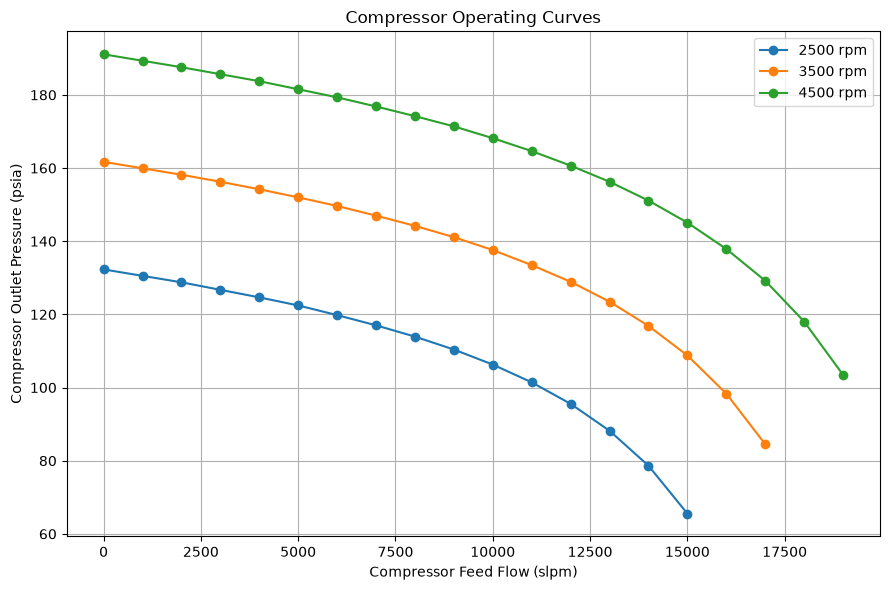

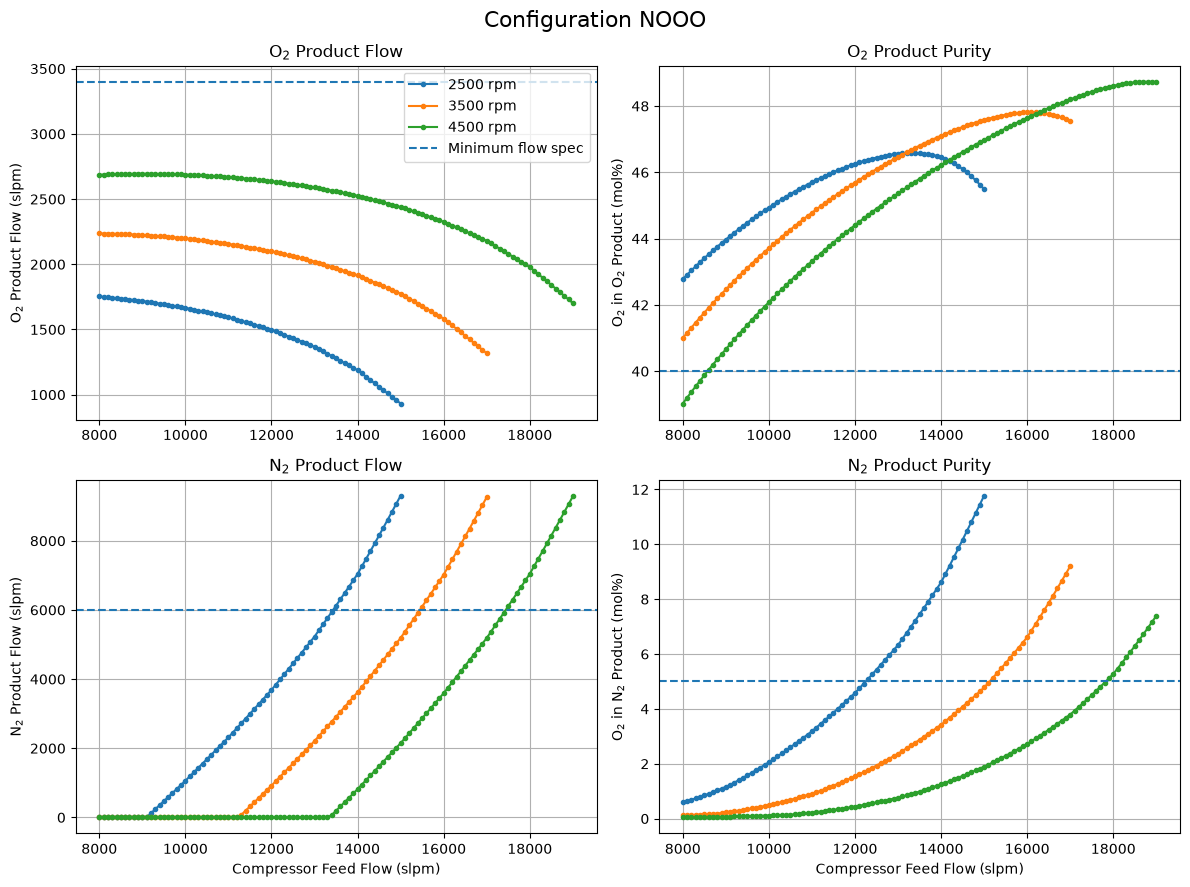

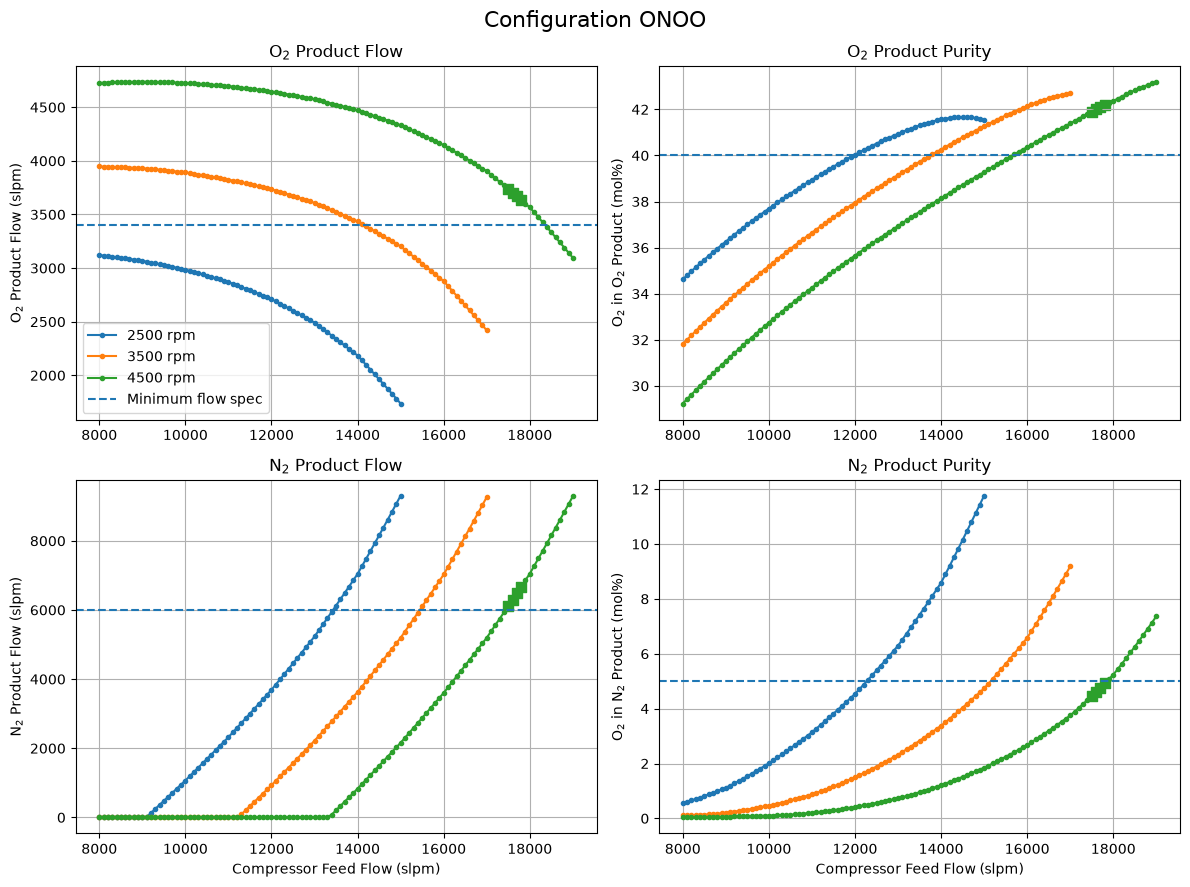

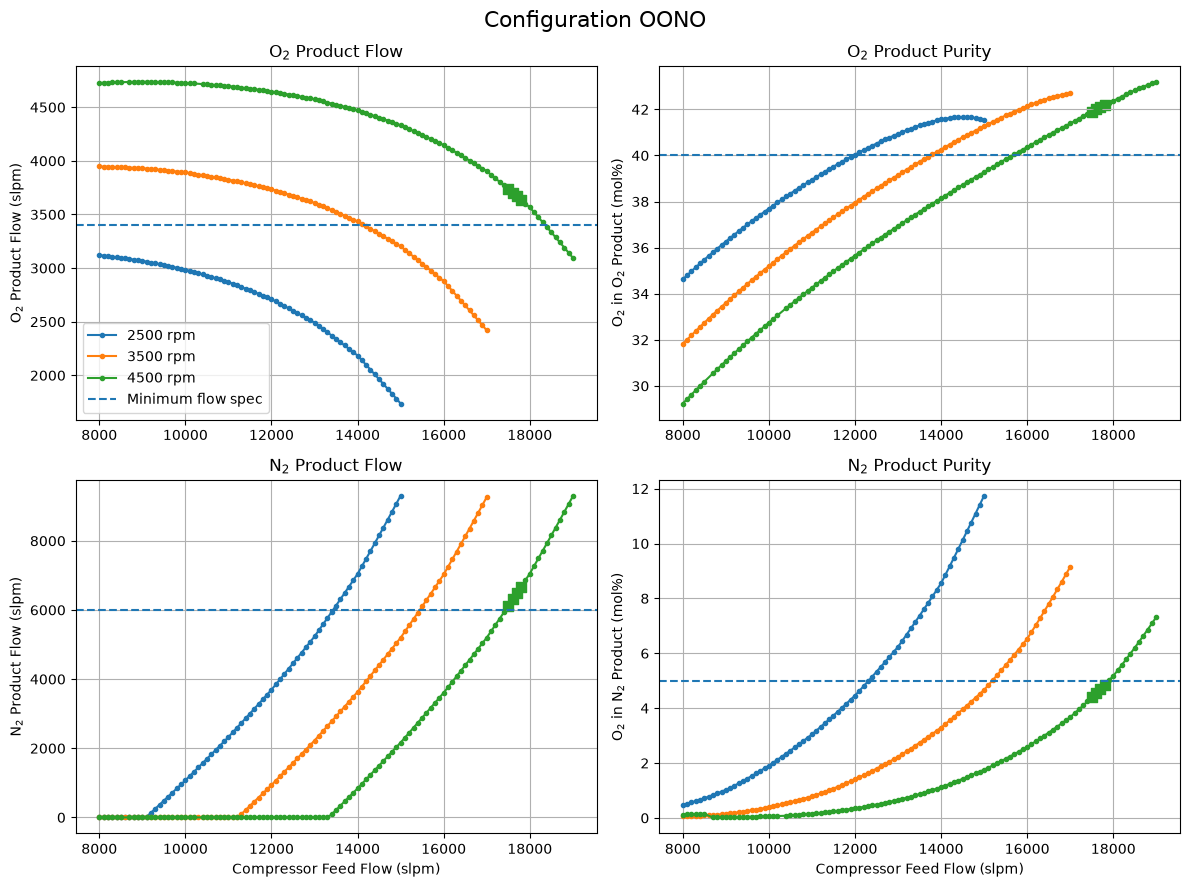

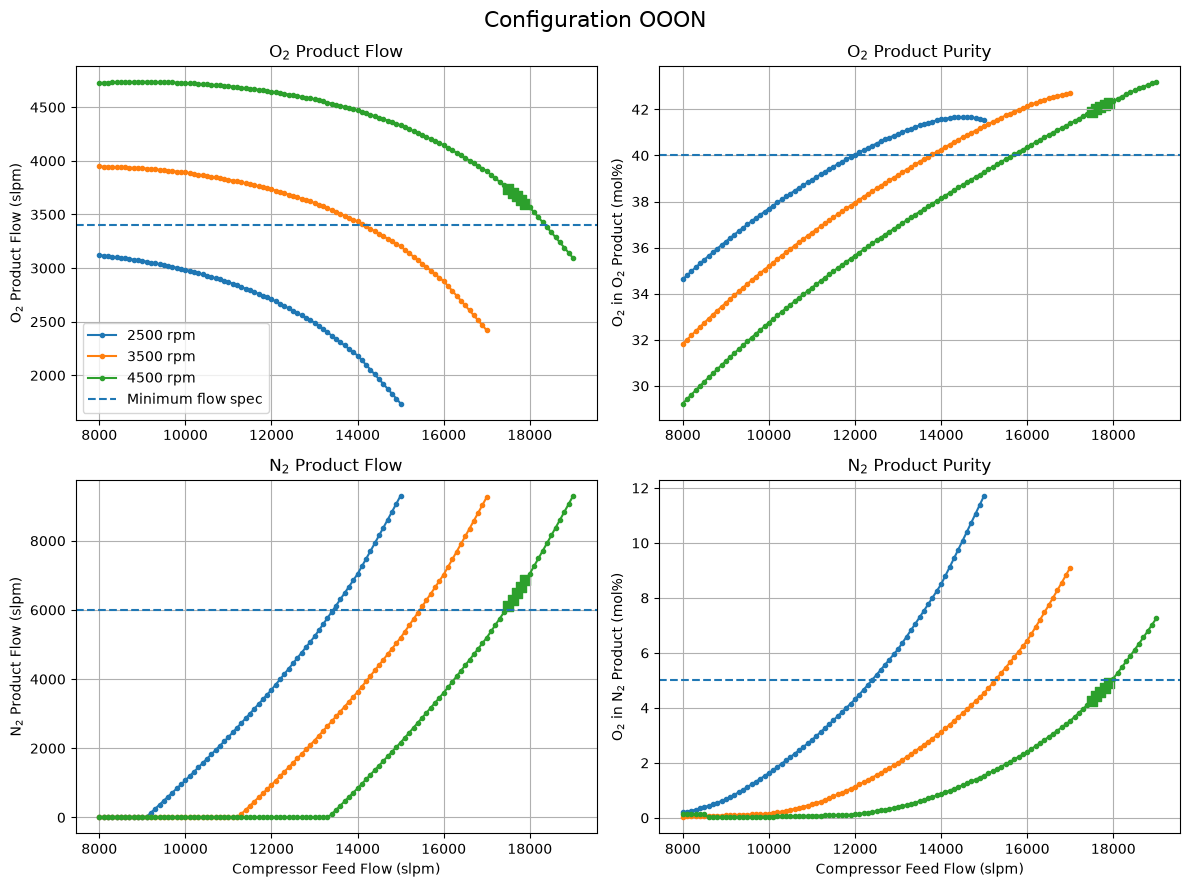

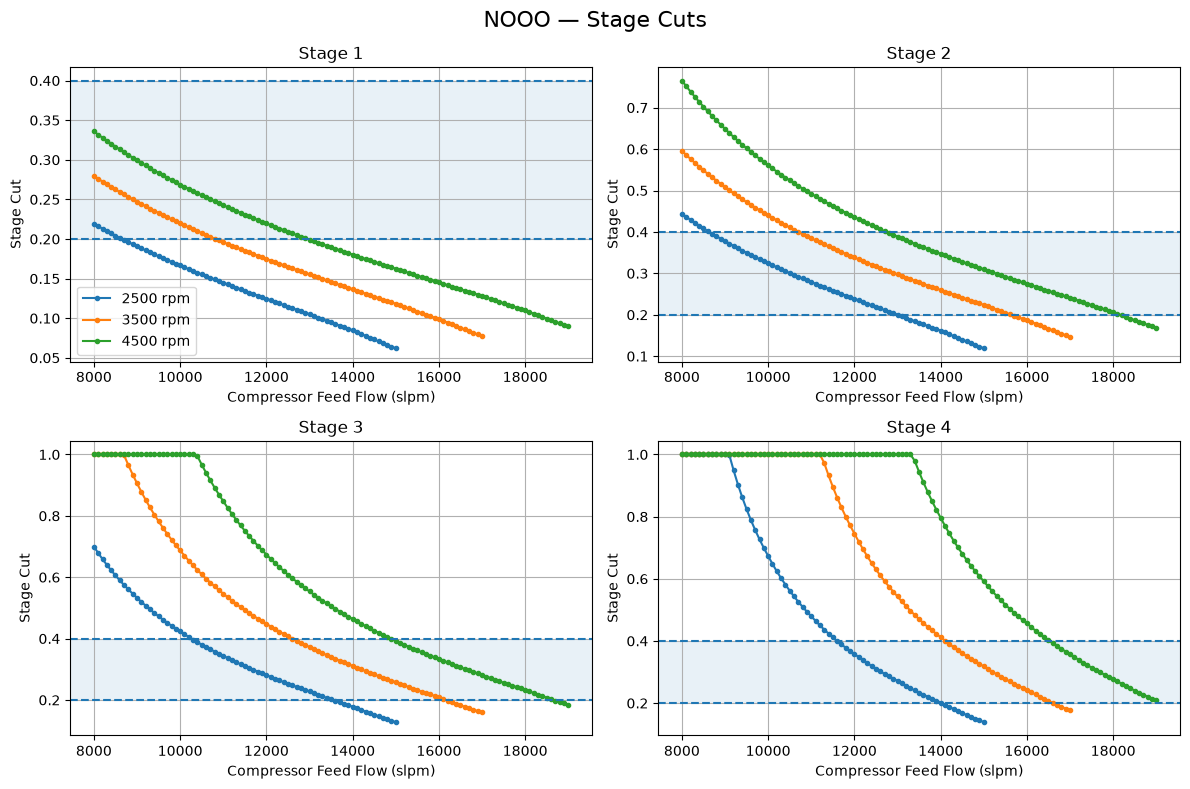

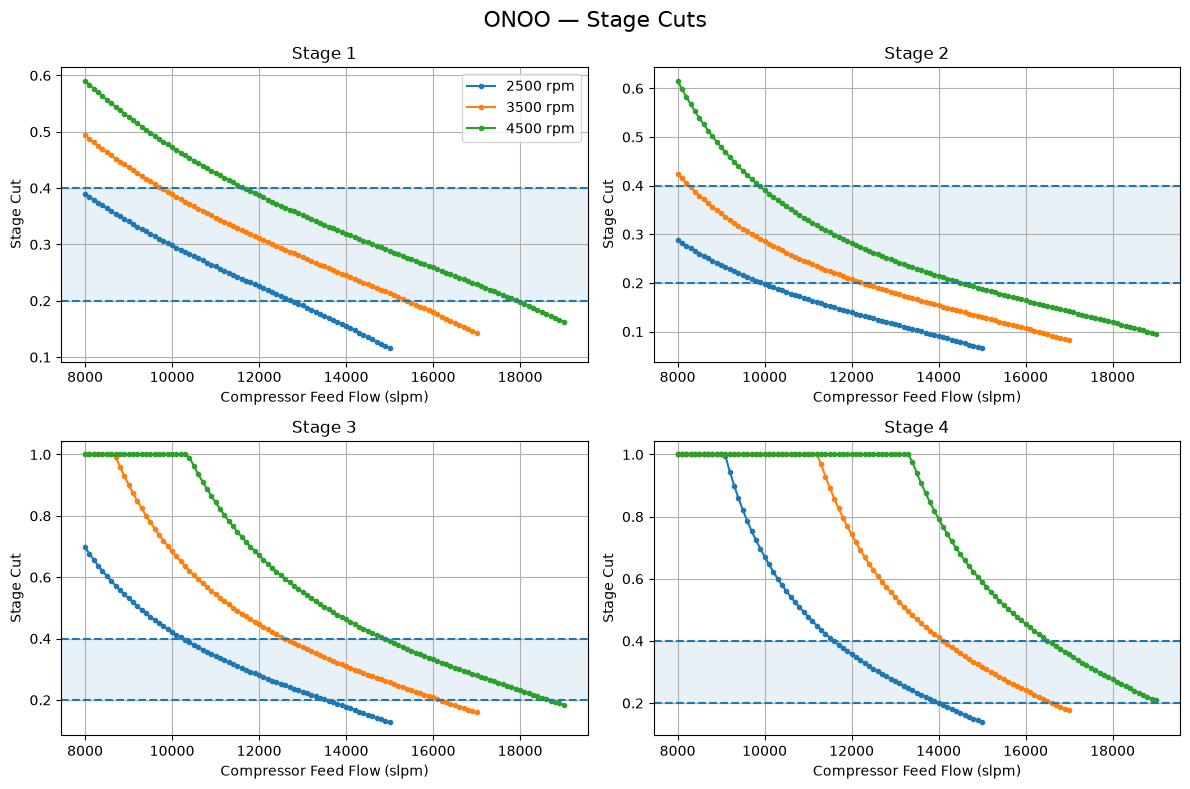

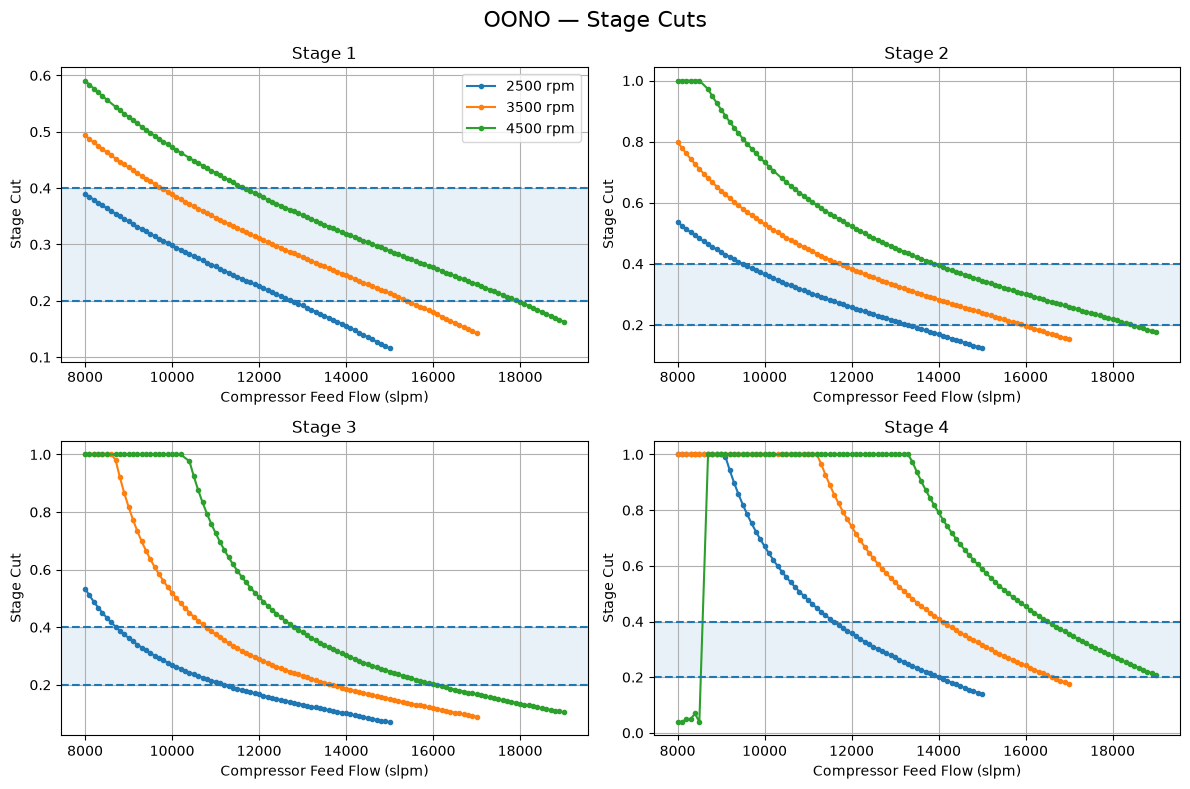

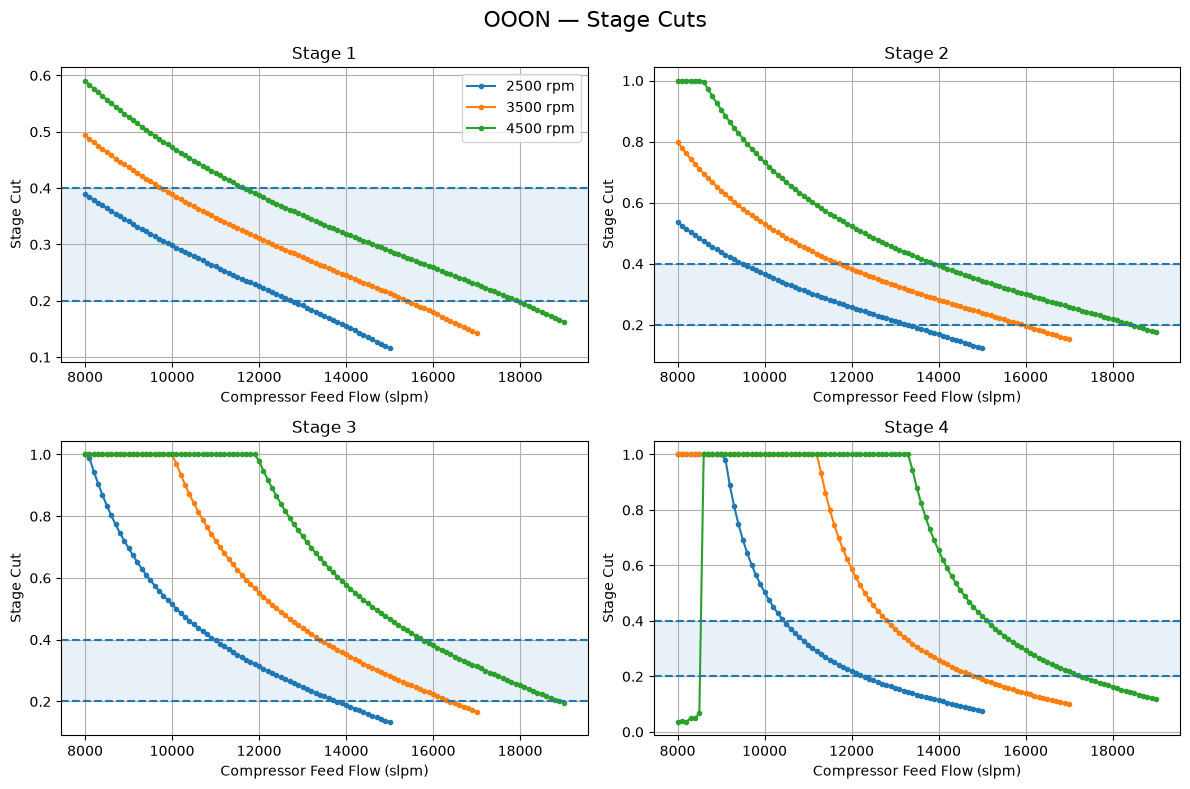

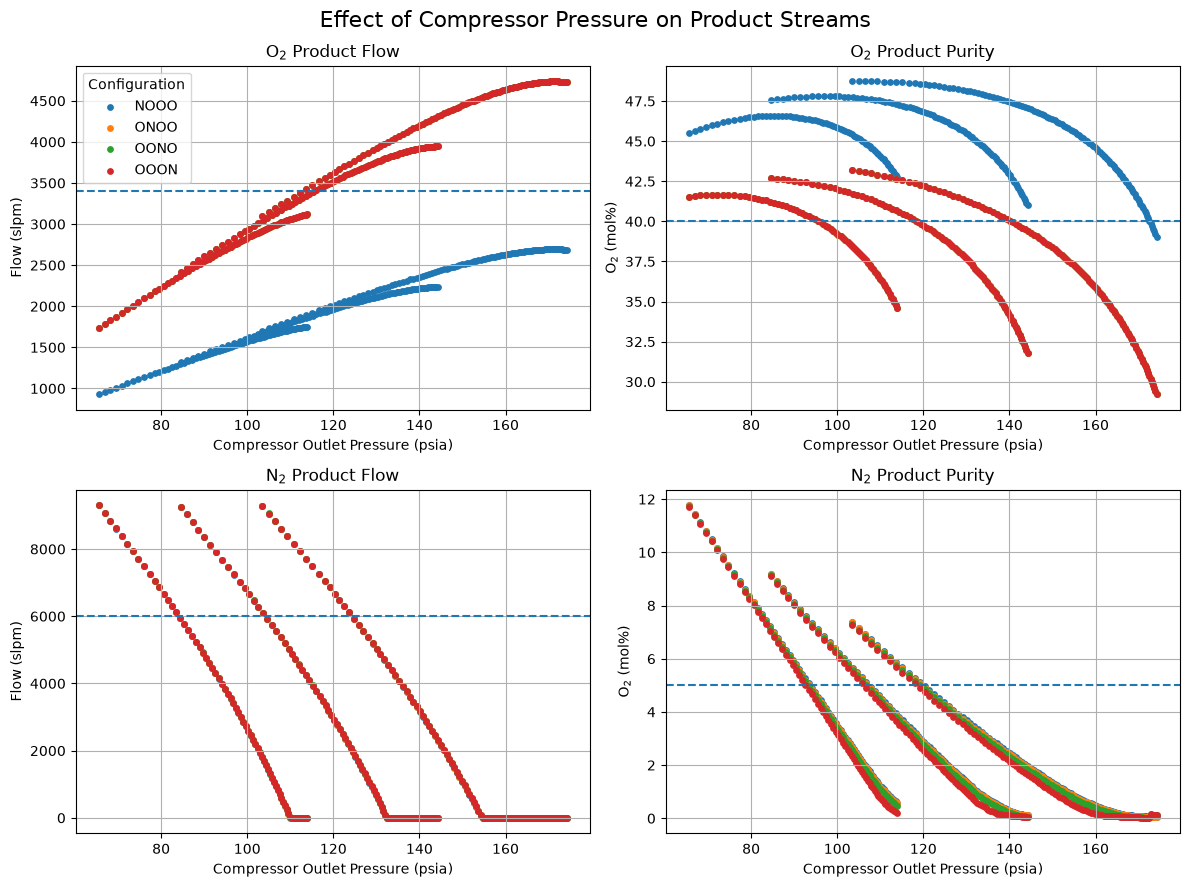



PRODUCT-SPEC FEASIBLE OPERATING WINDOWS
configuration  rpm  flow_min  flow_max  pressure_min  pressure_max  minimum_ideal_power  minimum_stage_cut  maximum_stage_cut
         ONOO 4500     17500     17800       120.275       123.627               94.521              0.124              0.314
         OONO 4500     17500     17800       120.275       123.627               94.521              0.141              0.313
         OOON 4500     17500     17900       119.158       123.627               94.492              0.168              0.281


LOWEST IDEAL-POWER FEASIBLE POINT FOR EACH CONFIGURATION
configuration  rpm  feed_flow  p_out_psia  p_ratio  O2_product_flow  O2_product_O2  N2_product_flow  N2_product_O2  theta_1  theta_2  theta_3  theta_4  stage_cuts_valid  ideal_power_kW
         ONOO 4500      17800    120.2754   8.1820        3634.8674         0.4219        6674.4021         0.0492   0.2042   0.1235   0.2417   0.2911             False         94.5212
         OONO 4500      1

,configuration,rpm,feed_flow,p_ratio,p_out_psia,O2_product_flow,O2_product_O2,N2_product_flow,N2_product_O2,theta_1,...,min_stage_cut,max_stage_cut,O2_flow_met,O2_purity_met,N2_flow_met,N2_purity_met,product_specs_met,stage_cuts_valid,stage_cut_penalty,ideal_power_kW
0,NOOO,2500,8000,7.750,113.9250,1753.920157,0.427797,0.001451,0.005904,0.219240,...,0.219240,1.000000,False,True,False,True,False,False,0.943692,41.034437
1,NOOO,2500,8100,7.726,113.5722,1750.719362,0.429116,0.001502,0.006378,0.216138,...,0.216138,1.000000,False,True,False,True,False,False,0.915297,41.464280
2,NOOO,2500,8200,7.702,113.2194,1747.438741,0.430405,0.001507,0.006873,0.213102,...,0.213102,1.000000,False,True,False,True,False,False,0.888272,41.891884
3,NOOO,2500,8300,7.678,112.8666,1744.079948,0.431665,0.001461,0.007389,0.210130,...,0.210130,1.000000,False,True,False,True,False,False,0.862514,42.317243
4,NOOO,2500,8400,7.654,112.5138,1740.644742,0.432897,0.001364,0.007927,0.207220,...,0.207220,1.000000,False,True,False,True,False,False,0.837931,42.740347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085,OOON,4500,18600,7.436,109.3092,3286.962208,0.429086,8378.333858,0.063416,0.176718,...,0.134385,0.216983,False,True,True,False,False,False,0.096133,92.874673
1086,OOON,4500,18700,7.337,107.8539,3239.604729,0.429870,8603.488218,0.065659,0.173241,...,0.130231,0.211494,False,True,True,False,False,False,0.107947,92.556021
1087,OOON,4500,18800,7.238,106.3986,3192.002756,0.430617,8829.775125,0.067934,0.169787,...,0.126223,0.206127,False,True,True,False,False,False,0.119540,92.220656
1088,OOON,4500,18900,7.139,104.9433,3144.157698,0.431325,9057.214270,0.070242,0.166358,...,0.122353,0.200875,False,True,True,False,False,False,0.130920,91.868263


,retentate_flow,permeate_flow,retentate_O2,permeate_O2,stage_cut,stage,membrane,configuration,rpm,feed_flow,p_out_psia
0,6246.079843,1753.920157,0.147561,0.427797,0.219240,1,N,NOOO,2500,8000,113.9250
1,3473.228779,2772.851064,0.076827,0.236161,0.443935,2,O,NOOO,2500,8000,113.9250
2,1042.810679,2430.418100,0.029274,0.097231,0.699758,3,O,NOOO,2500,8000,113.9250
3,0.001451,1042.810679,0.005904,0.029038,1.000000,4,O,NOOO,2500,8000,113.9250
4,6349.280638,1750.719362,0.148306,0.429116,0.216138,1,N,NOOO,2500,8100,113.5722
...,...,...,...,...,...,...,...,...,...,...,...
4355,9057.214270,1262.666298,0.070242,0.227461,0.122353,4,N,OOON,4500,18900,104.9433
4356,15903.928922,3096.071078,0.165589,0.431994,0.162951,1,O,OOON,4500,19000,103.4880
4357,13099.455781,2804.473140,0.126145,0.349829,0.176338,2,O,OOON,4500,19000,103.4880
4358,10535.454602,2564.001189,0.091619,0.268010,0.195733,3,O,OOON,4500,19000,103.4880


In [ ]:
# ============================================================
# LOAD COMPRESSOR DATA
# ============================================================

comp.columns = comp.columns.str.strip()


# ============================================================
# CONSTANTS / DESIGN SPECIFICATIONS
# ============================================================

new_area = 2500       # m^2
air_O2 = 0.209        # feed O2 mole fraction
Pin = 14.7            # compressor inlet pressure, psia
PP = 14.7             # membrane permeate pressure, psia

RPM_LIST = [2500, 3500, 4500]

# Product requirements
O2_FLOW_SPEC = 3400       # slpm
O2_PURITY_SPEC = 0.40     # mole fraction O2

N2_FLOW_SPEC = 6000       # slpm
N2_O2_SPEC = 0.05         # maximum O2 mole fraction

# Manufacturer recommended stage-cut range
STAGE_CUT_MIN = 0.20
STAGE_CUT_MAX = 0.40


# ============================================================
# MEMBRANE PROPERTIES
# ============================================================

old_membrane = {
    "area": 4000,
    "O2_perm": 0.031,
    "alpha": 5.5
}

new_membrane = {
    "area": new_area,
    "O2_perm": O2_perm,
    "alpha": alpha
}

# N = new membrane
# O = old membrane
configurations = [
    "NOOO",
    "ONOO",
    "OONO",
    "OOON"
]


# ============================================================
# COMPRESSOR FUNCTION
# ============================================================

def compressor(flowrate, rpm, Pin=14.7):
    """
    Interpolates the compressor curve to determine outlet
    pressure and pressure ratio at the specified flow rate.

    Parameters
    ----------
    flowrate : float
        Compressor volumetric feed flow, slpm

    rpm : int
        Compressor speed. Must be 2500, 3500, or 4500 rpm.

    Pin : float
        Compressor inlet pressure, psia

    Returns
    -------
    dict
        p_out   : compressor outlet pressure, psia
        p_ratio : Pout / Pin
    """

    if rpm not in RPM_LIST:
        raise ValueError(
            f"rpm must be one of {RPM_LIST}"
        )

    # Remove NaN values beyond the valid range of each curve
    curve = comp[["V", str(rpm)]].dropna()

    min_flow = curve["V"].min()
    max_flow = curve["V"].max()

    if not min_flow <= flowrate <= max_flow:
        raise ValueError(
            f"{rpm} rpm curve only covers "
            f"{min_flow:.0f} to {max_flow:.0f} slpm"
        )

    p_ratio = np.interp(
        flowrate,
        curve["V"],
        curve[str(rpm)]
    )

    Pout = p_ratio * Pin

    return {
        "p_out": Pout,
        "p_ratio": p_ratio
    }


# ============================================================
# IDEAL COMPRESSOR POWER
# ============================================================

def ideal_compressor_power(
    flow_slpm,
    p_ratio,
    T_in=298.15,
    gamma=1.4
    ):
    """
    Calculates approximate IDEAL isentropic compressor power.

    This is useful for comparing compressor operating points,
    but it is NOT actual motor power because compressor
    efficiency is not included.

    Parameters
    ----------
    flow_slpm : float
        Standard volumetric flow, slpm

    p_ratio : float
        Pout / Pin

    T_in : float
        Compressor inlet temperature, K

    gamma : float
        Cp/Cv for gas. Approximately 1.4 for air.

    Returns
    -------
    float
        Ideal compressor power, kW
    """

    R = 8.314          # J/(mol K)
    Vm_std = 22.414    # L/mol at standard conditions

    # slpm -> mol/s
    n_dot = flow_slpm / Vm_std / 60

    # Power for ideal, adiabatic, isentropic compressor with feed as room temp air
    power_W = (n_dot * gamma / (gamma - 1) * R * T_in * (p_ratio ** ((gamma - 1) / gamma) - 1))

    return power_W / 1000


# ============================================================
# SIMULATE ONE FOUR-STAGE CONFIGURATION
# ============================================================

def simulate_configuration(
    config,
    feed_flowrate,
    rpm,
    air_O2=0.209,
    Pin=14.7,
    PP=14.7
    ):
    """
    Runs one 4-stage membrane configuration at one compressor
    operating point.

    Product definitions:
        O2-rich product = Stage 1 permeate
        N2-rich product = Stage 4 retentate
    """

    # --------------------------------------------------------
    # Compressor
    # --------------------------------------------------------

    # Calculate feed pressure based on desired feed flow rate & compressor RPM
    comp_result = compressor(
        feed_flowrate,
        rpm,
        Pin
    )

    PR = comp_result["p_out"] # Set retentate pressure as feed pressure

    # --------------------------------------------------------
    # Membrane train
    # --------------------------------------------------------

    F = feed_flowrate # Given feed flow rate
    z = air_O2 # Given O2 concentration in air

    stages = []

    # Loop through each stage of the configuration (e.g. "O" or "N")
    for stage_num, membrane_type in enumerate(
        config,
        start=1
        ):

        # Use old membrane specs if "O"
        if membrane_type == "O":
            membrane = old_membrane

        # Use PRISM membrane specs if "N"
        elif membrane_type == "N":
            membrane = new_membrane

        # Raise error if configuration has invalid chars
        else:
            raise ValueError(
                "Configuration must contain only O and N."
            )

        # Obtain product streams and fractions from membrane_stage function
        stage = membrane_stage(
            F,
            z,
            membrane["area"],
            membrane["O2_perm"],
            membrane["alpha"],
            PR,
            PP
        )

        # Copy so we do not accidentally modify another object
        # This creates entirely new stage object, not a new reference
        stage = stage.copy()

        # Add stage number and membrane type fields to "stage" dict
        stage["stage"] = stage_num
        stage["membrane"] = membrane_type

        # Added dict object to "Stages" array
        stages.append(stage)

        # Retentate feeds next membrane
        F = stage["retentate_flow"]
        z = stage["retentate_O2"]

    # Transform array of stage dictionaries into single pandas dataframe
    stage_df = pd.DataFrame(stages)

    # --------------------------------------------------------
    # Product streams
    # --------------------------------------------------------

    # Extract direct stream conditions from configuration (O2 is S1 Perm, N2 is S4 Ret)
    O2_product_flow = stage_df.loc[
        0,
        "permeate_flow"
    ]

    O2_product_O2 = stage_df.loc[
        0,
        "permeate_O2"
    ]

    N2_product_flow = stage_df.loc[
        len(stage_df) - 1,
        "retentate_flow"
    ]

    N2_product_O2 = stage_df.loc[
        len(stage_df) - 1,
        "retentate_O2"
    ]

    # --------------------------------------------------------
    # Product specification checks
    # --------------------------------------------------------

    # Check if specifications were met
    O2_flow_met = (
        O2_product_flow >= O2_FLOW_SPEC
    )

    O2_purity_met = (
        O2_product_O2 >= O2_PURITY_SPEC
    )

    N2_flow_met = (
        N2_product_flow >= N2_FLOW_SPEC
    )

    N2_purity_met = (
        N2_product_O2 <= N2_O2_SPEC
    )

    product_specs_met = (
        O2_flow_met
        and O2_purity_met
        and N2_flow_met
        and N2_purity_met
    )

    # --------------------------------------------------------
    # Stage-cut checks
    # --------------------------------------------------------

    # This does some kind of scoring to quantify stage cut violations
    stage_cuts_valid = (
        stage_df["stage_cut"]
        .between(
            STAGE_CUT_MIN,
            STAGE_CUT_MAX
        )
        .all()
    )

    low_violation = np.maximum(
        0,
        STAGE_CUT_MIN - stage_df["stage_cut"]
    )

    high_violation = np.maximum(
        0,
        stage_df["stage_cut"] - STAGE_CUT_MAX
    )

    # Total amount by which stages lie outside 0.2-0.4
    stage_cut_penalty = (
        low_violation + high_violation
    ).sum()

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    # Compiles simulation data into single returnable dict
    summary = {
        "configuration": config,
        "rpm": rpm,

        "feed_flow": feed_flowrate,

        "p_ratio": comp_result["p_ratio"],
        "p_out_psia": PR,

        "O2_product_flow": O2_product_flow,
        "O2_product_O2": O2_product_O2,

        "N2_product_flow": N2_product_flow,
        "N2_product_O2": N2_product_O2,

        "theta_1": stage_df.loc[0, "stage_cut"],
        "theta_2": stage_df.loc[1, "stage_cut"],
        "theta_3": stage_df.loc[2, "stage_cut"],
        "theta_4": stage_df.loc[3, "stage_cut"],

        "min_stage_cut": stage_df["stage_cut"].min(),
        "max_stage_cut": stage_df["stage_cut"].max(),

        "O2_flow_met": O2_flow_met,
        "O2_purity_met": O2_purity_met,
        "N2_flow_met": N2_flow_met,
        "N2_purity_met": N2_purity_met,

        "product_specs_met": product_specs_met,
        "stage_cuts_valid": stage_cuts_valid,

        "stage_cut_penalty": stage_cut_penalty,

        "ideal_power_kW": ideal_compressor_power(
            feed_flowrate,
            comp_result["p_ratio"]
        )
    }

    return summary, stage_df


# ============================================================
# SWEEP ALL CONFIGURATIONS AND COMPRESSOR CONDITIONS
# ============================================================

def sweep_operating_points(
    configurations,
    flow_step=100,
    minimum_flow=8000
    ):
    """
    Tests all membrane configurations at all three RPMs over
    the valid flow range of each compressor curve.
    """

    summary_results = []
    stage_results = []

    # Test each RPM series
    for rpm in RPM_LIST:

        # Produce df with just flowrates and pressure ratios @ given RPM
        curve = comp[
            ["V", str(rpm)]
        ].dropna()

        # Create vector holding maximum allowable flowrate for given RPM
        max_flow = curve["V"].max()

        # Generate test flow rate vector with resolution "flow_step"
        flows = np.arange(
            minimum_flow,
            max_flow + flow_step,
            flow_step
        )

        # For each 4-membrane configuration...
        for config in configurations:

            # For each possible input flow rate we can feed each configuration
            for flow in flows:

                # Simulate that configuration, flow rate, and rpm
                try:

                    summary, stage_df = (
                        simulate_configuration(
                            config,
                            flow,
                            rpm
                        )
                    )

                # Raise an error if something breaks the simulation
                except (
                    RuntimeError,
                    ValueError
                ):
                    continue

                # Compile all the results into a list
                summary_results.append(
                    summary
                )

                # Copy the stage dataframe to prevent referencing issues
                stage_df = stage_df.copy()

                # Add following fields to the stage_df dict
                stage_df[
                    "configuration"
                ] = config

                stage_df[
                    "rpm"
                ] = rpm

                stage_df[
                    "feed_flow"
                ] = flow

                stage_df[
                    "p_out_psia"
                ] = summary[
                    "p_out_psia"
                ]

                # Copy resulting dict to the results list
                stage_results.append(
                    stage_df
                )

    # Convert results list of dicts into dataframe
    summary_df = pd.DataFrame(
        summary_results
    )

    if len(stage_results) > 0:

        stage_df = pd.concat(
            stage_results,
            ignore_index=True
        )

    else:

        stage_df = pd.DataFrame()

    return summary_df, stage_df


# ============================================================
# RUN SWEEP
# ============================================================

sweep, stage_sweep = sweep_operating_points(
    configurations,
    flow_step=100,
    minimum_flow=8000
)


# ============================================================
# FIGURE 1 — COMPRESSOR CURVES
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for rpm in RPM_LIST:

    curve = comp[
        ["V", str(rpm)]
    ].dropna()

    pressure = (
        curve[str(rpm)] * Pin
    )

    ax.plot(
        curve["V"],
        pressure,
        marker="o",
        label=f"{rpm} rpm"
    )

ax.set_xlabel(
    "Compressor Feed Flow (slpm)"
)

ax.set_ylabel(
    "Compressor Outlet Pressure (psia)"
)

ax.set_title(
    "Compressor Operating Curves"
)

ax.grid()

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FIGURES 2-5 — PRODUCT PERFORMANCE FOR EACH CONFIGURATION
# ============================================================

def plot_product_performance(sweep):

    for config in configurations:

        data = sweep[
            sweep["configuration"]
            == config
        ]

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(12, 9)
        )

        # ----------------------------------------------------
        # O2 PRODUCT FLOW
        # ----------------------------------------------------

        ax = axes[0, 0]

        for rpm in RPM_LIST:

            d = data[
                data["rpm"] == rpm
            ]

            ax.plot(
                d["feed_flow"],
                d["O2_product_flow"],
                marker="o",
                markersize=3,
                label=f"{rpm} rpm"
            )

            feasible = d[
                d["product_specs_met"]
            ]

            ax.scatter(
                feasible["feed_flow"],
                feasible["O2_product_flow"],
                marker="s",
                s=50
            )

        ax.axhline(
            O2_FLOW_SPEC,
            linestyle="--",
            label="Minimum flow spec"
        )

        ax.set_ylabel(
            "O$_2$ Product Flow (slpm)"
        )

        ax.set_title(
            "O$_2$ Product Flow"
        )

        ax.grid()
        ax.legend()

        # ----------------------------------------------------
        # O2 PRODUCT PURITY
        # ----------------------------------------------------

        ax = axes[0, 1]

        for rpm in RPM_LIST:

            d = data[
                data["rpm"] == rpm
            ]

            ax.plot(
                d["feed_flow"],
                100 * d["O2_product_O2"],
                marker="o",
                markersize=3,
                label=f"{rpm} rpm"
            )

            feasible = d[
                d["product_specs_met"]
            ]

            ax.scatter(
                feasible["feed_flow"],
                100 * feasible[
                    "O2_product_O2"
                ],
                marker="s",
                s=50
            )

        ax.axhline(
            100 * O2_PURITY_SPEC,
            linestyle="--"
        )

        ax.set_ylabel(
            "O$_2$ in O$_2$ Product (mol%)"
        )

        ax.set_title(
            "O$_2$ Product Purity"
        )

        ax.grid()

        # ----------------------------------------------------
        # N2 PRODUCT FLOW
        # ----------------------------------------------------

        ax = axes[1, 0]

        for rpm in RPM_LIST:

            d = data[
                data["rpm"] == rpm
            ]

            ax.plot(
                d["feed_flow"],
                d["N2_product_flow"],
                marker="o",
                markersize=3,
                label=f"{rpm} rpm"
            )

            feasible = d[
                d["product_specs_met"]
            ]

            ax.scatter(
                feasible["feed_flow"],
                feasible["N2_product_flow"],
                marker="s",
                s=50
            )

        ax.axhline(
            N2_FLOW_SPEC,
            linestyle="--"
        )

        ax.set_xlabel(
            "Compressor Feed Flow (slpm)"
        )

        ax.set_ylabel(
            "N$_2$ Product Flow (slpm)"
        )

        ax.set_title(
            "N$_2$ Product Flow"
        )

        ax.grid()

        # ----------------------------------------------------
        # N2 PRODUCT PURITY
        # ----------------------------------------------------

        ax = axes[1, 1]

        for rpm in RPM_LIST:

            d = data[
                data["rpm"] == rpm
            ]

            ax.plot(
                d["feed_flow"],
                100 * d["N2_product_O2"],
                marker="o",
                markersize=3,
                label=f"{rpm} rpm"
            )

            feasible = d[
                d["product_specs_met"]
            ]

            ax.scatter(
                feasible["feed_flow"],
                100 * feasible[
                    "N2_product_O2"
                ],
                marker="s",
                s=50
            )

        ax.axhline(
            100 * N2_O2_SPEC,
            linestyle="--"
        )

        ax.set_xlabel(
            "Compressor Feed Flow (slpm)"
        )

        ax.set_ylabel(
            "O$_2$ in N$_2$ Product (mol%)"
        )

        ax.set_title(
            "N$_2$ Product Purity"
        )

        ax.grid()

        fig.suptitle(
            f"Configuration {config}",
            fontsize=16
        )

        plt.tight_layout()
        plt.show()


plot_product_performance(sweep)


# ============================================================
# FIGURES 6-9 — STAGE CUTS FOR EACH CONFIGURATION
# ============================================================

def plot_stage_cuts(stage_sweep):

    for config in configurations:

        config_data = stage_sweep[
            stage_sweep["configuration"]
            == config
        ]

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(12, 8)
        )

        axes = axes.flatten()

        for stage_num in range(1, 5):

            ax = axes[
                stage_num - 1
            ]

            stage_data = config_data[
                config_data["stage"]
                == stage_num
            ]

            for rpm in RPM_LIST:

                d = stage_data[
                    stage_data["rpm"]
                    == rpm
                ]

                ax.plot(
                    d["feed_flow"],
                    d["stage_cut"],
                    marker="o",
                    markersize=3,
                    label=f"{rpm} rpm"
                )

            ax.axhline(
                STAGE_CUT_MIN,
                linestyle="--"
            )

            ax.axhline(
                STAGE_CUT_MAX,
                linestyle="--"
            )

            ax.axhspan(
                STAGE_CUT_MIN,
                STAGE_CUT_MAX,
                alpha=0.1
            )

            ax.set_title(
                f"Stage {stage_num}"
            )

            ax.set_xlabel(
                "Compressor Feed Flow (slpm)"
            )

            ax.set_ylabel(
                "Stage Cut"
            )

            ax.grid()

            if stage_num == 1:
                ax.legend()

        fig.suptitle(
            f"{config} — Stage Cuts",
            fontsize=16
        )

        plt.tight_layout()
        plt.show()


plot_stage_cuts(stage_sweep)


# ============================================================
# FIGURE 10 — PRESSURE VS PRODUCT PERFORMANCE
# ============================================================

def plot_pressure_effects(sweep):

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 9)
    )

    for config in configurations:

        d = sweep[
            sweep["configuration"]
            == config
        ]

        axes[0, 0].scatter(
            d["p_out_psia"],
            d["O2_product_flow"],
            s=15,
            label=config
        )

        axes[0, 1].scatter(
            d["p_out_psia"],
            100 * d["O2_product_O2"],
            s=15,
            label=config
        )

        axes[1, 0].scatter(
            d["p_out_psia"],
            d["N2_product_flow"],
            s=15,
            label=config
        )

        axes[1, 1].scatter(
            d["p_out_psia"],
            100 * d["N2_product_O2"],
            s=15,
            label=config
        )

    axes[0, 0].axhline(
        O2_FLOW_SPEC,
        linestyle="--"
    )

    axes[0, 1].axhline(
        100 * O2_PURITY_SPEC,
        linestyle="--"
    )

    axes[1, 0].axhline(
        N2_FLOW_SPEC,
        linestyle="--"
    )

    axes[1, 1].axhline(
        100 * N2_O2_SPEC,
        linestyle="--"
    )

    axes[0, 0].set_title(
        "O$_2$ Product Flow"
    )

    axes[0, 1].set_title(
        "O$_2$ Product Purity"
    )

    axes[1, 0].set_title(
        "N$_2$ Product Flow"
    )

    axes[1, 1].set_title(
        "N$_2$ Product Purity"
    )

    axes[0, 0].set_ylabel(
        "Flow (slpm)"
    )

    axes[0, 1].set_ylabel(
        "O$_2$ (mol%)"
    )

    axes[1, 0].set_ylabel(
        "Flow (slpm)"
    )

    axes[1, 1].set_ylabel(
        "O$_2$ (mol%)"
    )

    for ax in axes.flatten():

        ax.set_xlabel(
            "Compressor Outlet Pressure (psia)"
        )

        ax.grid()

    axes[0, 0].legend(
        title="Configuration"
    )

    fig.suptitle(
        "Effect of Compressor Pressure on Product Streams",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


plot_pressure_effects(sweep)


# ============================================================
# PRINT ALL PRODUCT-FEASIBLE OPERATING WINDOWS
# ============================================================

feasible = sweep[
    sweep["product_specs_met"]
].copy()

print("\n")
print("=" * 80)
print("PRODUCT-SPEC FEASIBLE OPERATING WINDOWS")
print("=" * 80)

if feasible.empty:

    print(
        "No operating points meet all four product specifications."
    )

else:

    operating_windows = (
        feasible
        .groupby(
            [
                "configuration",
                "rpm"
            ]
        )
        .agg(
            flow_min=(
                "feed_flow",
                "min"
            ),

            flow_max=(
                "feed_flow",
                "max"
            ),

            pressure_min=(
                "p_out_psia",
                "min"
            ),

            pressure_max=(
                "p_out_psia",
                "max"
            ),

            minimum_ideal_power=(
                "ideal_power_kW",
                "min"
            ),

            minimum_stage_cut=(
                "min_stage_cut",
                "min"
            ),

            maximum_stage_cut=(
                "max_stage_cut",
                "max"
            )
        )
        .reset_index()
    )

    print(
        operating_windows.to_string(
            index=False,
            float_format=lambda x: f"{x:.3f}"
        )
    )


# ============================================================
# PRINT LOWEST-POWER PRODUCT-FEASIBLE POINT
# FOR EACH CONFIGURATION
# ============================================================

print("\n")
print("=" * 80)
print("LOWEST IDEAL-POWER FEASIBLE POINT FOR EACH CONFIGURATION")
print("=" * 80)

if feasible.empty:

    print(
        "No feasible operating points."
    )

else:

    best_power = (
        feasible
        .sort_values(
            "ideal_power_kW"
        )
        .groupby(
            "configuration",
            as_index=False
        )
        .first()
    )

    columns = [
        "configuration",
        "rpm",
        "feed_flow",
        "p_out_psia",
        "p_ratio",

        "O2_product_flow",
        "O2_product_O2",

        "N2_product_flow",
        "N2_product_O2",

        "theta_1",
        "theta_2",
        "theta_3",
        "theta_4",

        "stage_cuts_valid",
        "ideal_power_kW"
    ]

    print(
        best_power[
            columns
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# ============================================================
# PRINT PRODUCT-FEASIBLE POINT WITH SMALLEST
# STAGE-CUT VIOLATION FOR EACH CONFIGURATION
# ============================================================

print("\n")
print("=" * 80)
print("FEASIBLE POINT WITH SMALLEST STAGE-CUT VIOLATION")
print("=" * 80)

if feasible.empty:

    print(
        "No feasible operating points."
    )

else:

    best_stage_cut = (
        feasible
        .sort_values(
            [
                "stage_cut_penalty",
                "ideal_power_kW"
            ]
        )
        .groupby(
            "configuration",
            as_index=False
        )
        .first()
    )

    columns = [
        "configuration",
        "rpm",
        "feed_flow",
        "p_out_psia",

        "O2_product_flow",
        "O2_product_O2",

        "N2_product_flow",
        "N2_product_O2",

        "theta_1",
        "theta_2",
        "theta_3",
        "theta_4",

        "stage_cut_penalty",
        "ideal_power_kW"
    ]

    print(
        best_stage_cut[
            columns
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# ============================================================
# STRICT FEASIBILITY:
# PRODUCT SPECS + ALL STAGE CUTS BETWEEN 0.2 AND 0.4
# ============================================================

strictly_feasible = sweep[
    sweep["product_specs_met"]
    & sweep["stage_cuts_valid"]
].copy()

print("\n")
print("=" * 80)
print("POINTS MEETING BOTH PRODUCT SPECS AND STAGE-CUT RANGE")
print("=" * 80)

if strictly_feasible.empty:

    print(
        "No operating points satisfy both the product "
        "specifications and the 0.20-0.40 stage-cut range."
    )

else:

    strictly_feasible = (
        strictly_feasible
        .sort_values(
            "ideal_power_kW"
        )
    )

    columns = [
        "configuration",
        "rpm",
        "feed_flow",
        "p_out_psia",

        "O2_product_flow",
        "O2_product_O2",

        "N2_product_flow",
        "N2_product_O2",

        "theta_1",
        "theta_2",
        "theta_3",
        "theta_4",

        "ideal_power_kW"
    ]

    print(
        strictly_feasible[
            columns
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# ============================================================
# OVERALL BEST CANDIDATE
#
# Ranking:
# 1. Must meet product specifications
# 2. Prefer smallest stage-cut violation
# 3. Then prefer lowest ideal compressor power
# ============================================================

print("\n")
print("=" * 80)
print("OVERALL BEST PRODUCT-FEASIBLE CANDIDATE")
print("=" * 80)

if feasible.empty:

    print(
        "No candidate meets all four product specifications."
    )

else:

    ranked = feasible.sort_values(
        [
            "stage_cut_penalty",
            "ideal_power_kW"
        ]
    )

    best = ranked.iloc[0]

    print(
        f"Configuration:             {best['configuration']}"
    )

    print(
        f"Compressor speed:          {best['rpm']:.0f} rpm"
    )

    print(
        f"Feed flow:                 {best['feed_flow']:.0f} slpm"
    )

    print(
        f"Compressor outlet:         {best['p_out_psia']:.2f} psia"
    )

    print(
        f"Pressure ratio:            {best['p_ratio']:.3f}"
    )

    print()

    print(
        f"O2 product flow:           "
        f"{best['O2_product_flow']:.1f} slpm"
    )

    print(
        f"O2 product composition:    "
        f"{100 * best['O2_product_O2']:.2f} mol% O2"
    )

    print()

    print(
        f"N2 product flow:           "
        f"{best['N2_product_flow']:.1f} slpm"
    )

    print(
        f"N2 product composition:    "
        f"{100 * best['N2_product_O2']:.2f} mol% O2"
    )

    print()

    print(
        "Stage cuts:                "
        f"{best['theta_1']:.3f}, "
        f"{best['theta_2']:.3f}, "
        f"{best['theta_3']:.3f}, "
        f"{best['theta_4']:.3f}"
    )

    print(
        f"All stage cuts 0.2-0.4:    "
        f"{best['stage_cuts_valid']}"
    )

    print(
        f"Stage-cut penalty:         "
        f"{best['stage_cut_penalty']:.4f}"
    )

    print(
        f"Ideal compressor power:    "
        f"{best['ideal_power_kW']:.2f} kW"
    )


# ============================================================
# OPTIONAL:
# SHOW THE FULL SWEEP DATAFRAME
# ============================================================

display(sweep)


# ============================================================
# OPTIONAL:
# SHOW ALL STAGE-BY-STAGE DATA
# ============================================================

display(stage_sweep)

# Save data as .csv's
sweep.to_csv(f"{home}/analyzed-data/summary.csv")
stage_sweep.to_csv(f"{home}/analyzed-data/stage.csv")